# 光纤路径与按名字读取 TDMS 信号热图

这个 notebook 做第一步复现准备：

- 读取本仓库 `FiberPath`，绘制 2D 光纤折线路径、节点、通道位置。
- 按 `name` 在 `DATA_DIR` 约定的数据目录中读取 Airtag / Video / DAS，并生成 DAS 信号 CSV。
- 默认对完整信号生成全时长短时能量热图，并缓存能量矩阵，避免重复扫描大 CSV。

如果目标 CSV 不存在，notebook 会直接在代码单元内从 Airtag 时间窗和 TDMS 中切出 CSV。

In [79]:
from pathlib import Path
import csv
import hashlib
import json
import math
import re
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.unicode_minus"] = False

# ===== 基本路径 =====
PROJECT_ROOT = Path.cwd()
DATA_DIR = Path(r"D:\WeaklySupervisedFootstep\Data")
FIBER_PATH_FILE = PROJECT_ROOT / "FiberPath"

# ===== 数据目录约定：DATA_DIR 下固定放 Airtag / Video / DAS =====
AIRTAG_DIR = DATA_DIR / "Airtag"
VIDEO_DIR = DATA_DIR / "Video"
TDMS_DIR = DATA_DIR / "DAS"
SIGNAL_OUTPUT_DIR = PROJECT_ROOT / "output" / "name_signals"
SIGNAL_CSV_OVERRIDE = None  # 例如 Path(r"D:\path\to\name.csv")；None 时按 NAME 自动查找/生成

# ===== DAS / TDMS 参数 =====
DAS_FS = 2000.0
CSV_UTC_OFFSET_HOURS = 8.0
OVERWRITE_CSV = False

# ===== 光纤路径与通道映射参数 =====
# FiberPath 当前为 3 列坐标，默认取第 1 列和第 3 列作为 2D 平面 x/y。
# 数值若像厘米或毫米坐标，会自动缩放；也可以设为 0.01 / 0.001 / 1.0。
PATH_COORD_SCALE = "auto"
PATH_2D_COLUMNS = (0, 2)
ACTIVE_CHANNEL_COUNT = 100
CHANNEL_LENGTH_M = 1.0

# ===== 热图参数：默认完整数据，全时长扫描 =====
TIME_START_S = None
TIME_END_S = None
ENERGY_WIN_MS = 100.0
ENERGY_STEP_MS = 25.0
CSV_CHUNKSIZE_ROWS = 200_000
FORCE_REBUILD_CACHE = False
CACHE_DIR = PROJECT_ROOT / "output" / "notebook_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = False

# 只影响显示速度和图片大小；None 表示显示完整热图帧。
DISPLAY_MAX_TIME_BINS = None

# ===== 阶段一/二执行控制：执行对应 cell 时默认直接出图 =====
RUN_PREPROCESSING_ON_EXECUTE = True
RUN_DETECTION_ON_EXECUTE = True
PREPROCESSING_MAX_DURATION_S = None  # None 表示完整时长；调试时可设成 60.0
BAND_COMPARE_MAX_PLOT_S = None  # None 表示阶段一 c-t 图显示全通道、全时间
PREPROCESS_DOWNSAMPLE_TO = None  # None 表示保持原始 2000 Hz，不做初始降采样
SINGLE_CHANNEL_PLOT_CHANNEL = 50

# 阶段二默认采用当前仓库 TDMS2FilteredSignalPlot.py 的检测参数风格：5-10 Hz + RMS 包络 + MAD 阈值。
DETECTION_BAND = (5, 10)
DETECTION_MAX_PLOT_S = 30.0
DETECTION_ENV_WIN_SEC = 0.5
DETECTION_ENV_HOP_SEC = 0.1
DETECTION_MAD_K = 2.5
DETECTION_MIN_CC_AREA = 50
DETECTION_MIN_ACTIVE_CHANNELS = 3
DETECTION_MIN_EVENT_DURATION_S = 0.08
DETECTION_MERGE_GAP_S = 0.25

# ===== 可用名字列表：优先来自 Airtag 与 Video 文件名交集；DAS 是公共 TDMS 目录，不参与按名字求交 =====
VIDEO_SUFFIXES = {".mp4", ".mov", ".avi", ".mkv"}


def _stems(folder, suffixes):
    folder = Path(folder)
    if not folder.exists():
        return set()
    if isinstance(suffixes, str):
        suffixes = {suffixes.lower()}
    else:
        suffixes = {s.lower() for s in suffixes}
    return {p.stem.lower() for p in folder.iterdir() if p.is_file() and p.suffix.lower() in suffixes}


AIRTAG_NAMES = _stems(AIRTAG_DIR, ".csv")
VIDEO_NAMES = _stems(VIDEO_DIR, VIDEO_SUFFIXES)
if VIDEO_NAMES:
    AVAILABLE_NAMES = sorted(AIRTAG_NAMES & VIDEO_NAMES)
    AVAILABLE_NAME_SOURCE = "Airtag ∩ Video"
else:
    AVAILABLE_NAMES = sorted(AIRTAG_NAMES)
    AVAILABLE_NAME_SOURCE = "Airtag only (Video directory has no matching files)"

# ===== 目标名字：改这里即可；建议从 AVAILABLE_NAMES 中选择 =====
NAME = "aipumin"

print(f"Project: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Airtag: {AIRTAG_DIR}")
print(f"Video: {VIDEO_DIR}")
print(f"DAS: {TDMS_DIR}")
print(f"Available names from {AVAILABLE_NAME_SOURCE} ({len(AVAILABLE_NAMES)}): {AVAILABLE_NAMES}")

Project: d:\DAS2Steps
DATA_DIR: D:\WeaklySupervisedFootstep\Data
Airtag: D:\WeaklySupervisedFootstep\Data\Airtag
Video: D:\WeaklySupervisedFootstep\Data\Video
DAS: D:\WeaklySupervisedFootstep\Data\DAS
Available names from Airtag only (Video directory has no matching files) (38): ['aipumin', 'daiweijia', 'fangjiayong', 'geningyu', 'hanyeyibo', 'hejunchen', 'heyuhang', 'huyutong', 'jingema', 'jintailin', 'liboyan', 'liubin', 'liujunze', 'liwenzhe', 'liyihong', 'liying', 'lizhuolin', 'loumingxuan', 'panzihao', 'sunjianfeng', 'sunshangjun', 'wangdihai', 'wangjiahui', 'wangqixiang', 'wangyueyang', 'wangziheng', 'wuhongjin', 'wuqinghan', 'wuwenxuan', 'xiayi', 'yangchen', 'yaojiayang', 'zengchuijing', 'zhangguangyuan', 'zhangtianrui', 'zhixingrui', 'zhouxueyang', 'ziyanghao']


## 1. 读取并绘制光纤路径

In [80]:
def _auto_coord_scale(points):
    max_abs = float(np.nanmax(np.abs(points)))
    if max_abs > 10_000:
        return 0.001, "mm -> m"
    if max_abs > 200:
        return 0.01, "cm -> m"
    return 1.0, "m"


def load_fiber_path(path, coord_scale="auto", xy_cols=(0, 2)):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    pts = np.loadtxt(path, dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    if pts.shape[1] < max(xy_cols) + 1:
        raise ValueError(f"FiberPath 至少需要 {max(xy_cols) + 1} 列坐标，当前 shape={pts.shape}")
    if coord_scale == "auto":
        scale, scale_note = _auto_coord_scale(pts[:, list(xy_cols)])
    else:
        scale = float(coord_scale)
        scale_note = f"x{scale}"
    xy = pts[:, list(xy_cols)] * scale
    seg_vec = np.diff(xy, axis=0)
    seg_len = np.linalg.norm(seg_vec, axis=1)
    s = np.r_[0.0, np.cumsum(seg_len)]
    df = pd.DataFrame({"node": np.arange(len(xy)), "x_m": xy[:, 0], "y_m": xy[:, 1], "s_m": s})
    return df, float(s[-1]), scale, scale_note


def interpolate_polyline(path_df, distances_m):
    s_nodes = path_df["s_m"].to_numpy(float)
    xy_nodes = path_df[["x_m", "y_m"]].to_numpy(float)
    distances_m = np.asarray(distances_m, dtype=float)
    out = np.full((len(distances_m), 2), np.nan, dtype=float)
    valid = (distances_m >= s_nodes[0]) & (distances_m <= s_nodes[-1])
    for i, d in enumerate(distances_m):
        if not valid[i]:
            continue
        j = np.searchsorted(s_nodes, d, side="right") - 1
        j = min(max(j, 0), len(s_nodes) - 2)
        denom = s_nodes[j + 1] - s_nodes[j]
        t = 0.0 if denom == 0 else (d - s_nodes[j]) / denom
        out[i] = xy_nodes[j] * (1.0 - t) + xy_nodes[j + 1] * t
    return out, valid


def channel_distance_m(channel_ids):
    channel_ids = np.asarray(channel_ids, dtype=float)
    return channel_ids * CHANNEL_LENGTH_M


def channel_xy(channel_ids, path_df):
    return interpolate_polyline(path_df, channel_distance_m(channel_ids))


fiber_df, fiber_len_m, coord_scale, scale_note = load_fiber_path(
    FIBER_PATH_FILE, coord_scale=PATH_COORD_SCALE, xy_cols=PATH_2D_COLUMNS
)
fiber_df

,node,x_m,y_m,s_m
0,0,0.0,0.0,0.0
1,1,0.0,6.9,6.9
2,2,-9.6,6.9,16.5
3,3,-9.6,15.2,24.8
4,4,15.0,15.2,49.4
5,5,15.0,9.0,55.6
6,6,17.4,9.0,58.0
7,7,17.4,-33.0,100.0


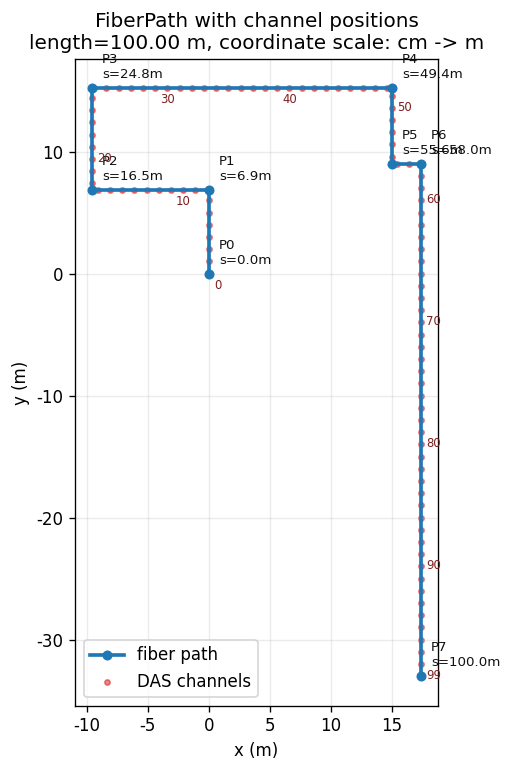

In [81]:
def plot_fiber_path(path_df, channel_ids=None, title="Fiber path"):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(path_df["x_m"], path_df["y_m"], "-o", color="#1f77b4", lw=2.2, ms=5, label="fiber path")
    for _, row in path_df.iterrows():
        ax.annotate(
            f"P{int(row.node)}\ns={row.s_m:.1f}m",
            (row.x_m, row.y_m),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=8,
            color="#111111",
        )

    if channel_ids is None:
        channel_ids = np.arange(ACTIVE_CHANNEL_COUNT, dtype=int)
    channel_ids = np.asarray(channel_ids, dtype=int)
    xy, valid = channel_xy(channel_ids, path_df)
    valid_ids = channel_ids[valid]
    valid_xy = xy[valid]
    ax.scatter(valid_xy[:, 0], valid_xy[:, 1], s=10, color="#d62728", alpha=0.55, label="DAS channels")

    if len(valid_ids):
        label_step = max(1, int(round(10 / CHANNEL_LENGTH_M)))
        for ch, (x, y) in zip(valid_ids, valid_xy):
            if ch == valid_ids[0] or ch == valid_ids[-1] or (ch % label_step == 0):
                ax.annotate(str(ch), (x, y), textcoords="offset points", xytext=(3, -9), fontsize=7, color="#7f1d1d")

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"{title}\nlength={fiber_len_m:.2f} m, coordinate scale: {scale_note}")
    ax.legend(loc="best")
    return fig, ax


fig, ax = plot_fiber_path(fiber_df, title="FiberPath with channel positions")
fiber_png = CACHE_DIR / "fiber_path_channels.png"
if SAVE_FIGURES:
    fig.savefig(fiber_png, bbox_inches="tight")
    print(f"Saved: {fiber_png}")
plt.show()

## 2. 按名字查找或从 TDMS 生成信号 CSV

In [82]:
TDMS_TIME_PATTERN = re.compile(r"_UTC_(\d{8}_\d{6}\.\d+)\.tdms$", re.IGNORECASE)
DATETIME_FORMATS = (
    "%Y-%m-%d  %H:%M:%S", "%Y/%m/%d  %H:%M:%S",
    "%Y-%m-%d %H:%M:%S", "%Y/%m/%d %H:%M:%S",
    "%Y-%m-%d  %H:%M:%S.%f", "%Y/%m/%d  %H:%M:%S.%f",
    "%Y-%m-%d %H:%M:%S.%f", "%Y/%m/%d %H:%M:%S.%f",
)


def parse_datetime(text):
    s = str(text).strip().replace("T", " ")
    for fmt in DATETIME_FORMATS:
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            pass
    raise ValueError(f"Unsupported datetime format: {text!r}")


def find_file_by_stem(folder, stem, suffix):
    stem = stem.lower().strip()
    matches = [p for p in Path(folder).glob(f"*{suffix}") if p.stem.lower() == stem]
    return matches[0] if matches else None


def read_airtag_start_end(csv_path, encoding="utf-8-sig"):
    first_dt = None
    last_dt = None
    with Path(csv_path).open("r", encoding=encoding, newline="") as f:
        reader = csv.reader(f)
        header = next(reader, None)
        if not header or not str(header[0]).strip().lower().startswith("datetime"):
            raise ValueError(f"Airtag CSV 第一列表头应以 datetime 开头: {csv_path}")
        for row in reader:
            if not row or not row[0].strip():
                continue
            dt = parse_datetime(row[0])
            if first_dt is None:
                first_dt = dt
            last_dt = dt
    if first_dt is None or last_dt is None:
        raise ValueError(f"Airtag CSV 没有有效 datetime 行: {csv_path}")
    return first_dt, last_dt


def parse_tdms_start(path):
    m = TDMS_TIME_PATTERN.search(Path(path).name)
    if not m:
        raise ValueError(f"Cannot parse UTC timestamp from TDMS name: {Path(path).name}")
    return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S.%f")


def build_tdms_index(tdms_dir, default_duration_sec=60.0):
    files = sorted(Path(tdms_dir).glob("*.tdms"), key=lambda p: p.name)
    if not files:
        raise FileNotFoundError(f"No TDMS files found in {tdms_dir}")
    starts = [(p, parse_tdms_start(p)) for p in files]
    starts.sort(key=lambda item: item[1])
    index = []
    for i, (path, start_utc) in enumerate(starts):
        end_utc = starts[i + 1][1] if i + 1 < len(starts) else start_utc + timedelta(seconds=default_duration_sec)
        index.append({"path": path, "start_utc": start_utc, "end_utc": end_utc})
    return index


def choose_overlapping_tdms(index, start_utc, end_utc):
    return [item for item in index if item["start_utc"] <= end_utc and item["end_utc"] >= start_utc]


def extraction_indices(file_start_utc, fs, n_samples, seg_start_utc, seg_end_utc):
    dt0 = (seg_start_utc - file_start_utc).total_seconds()
    dt1 = (seg_end_utc - file_start_utc).total_seconds()
    start_idx = int(math.ceil(dt0 * fs - 1e-9))
    end_exclusive = int(math.floor(dt1 * fs + 1e-9)) + 1
    start_idx = max(0, start_idx)
    end_exclusive = min(n_samples, end_exclusive)
    return start_idx, max(start_idx, end_exclusive)


def list_tdms_channels(tdms_file):
    channels = []
    for group in tdms_file.groups():
        channels.extend(group.channels())
    return channels


def write_signal_array_csv(path, data, write_header, append):
    mode = "a" if append else "w"
    with Path(path).open(mode, encoding="utf-8", newline="") as f:
        if write_header:
            f.write(",".join(f"ch_{i}" for i in range(data.shape[1])) + "\n")
        if data.size:
            fmt = "%d" if np.issubdtype(data.dtype, np.integer) else "%.10g"
            np.savetxt(f, data, delimiter=",", fmt=fmt)


def candidate_signal_csvs(name):
    n = name.lower().strip()
    return [SIGNAL_OUTPUT_DIR / f"{n}.csv"]


def signal_csv_matches_current_channel_config(path):
    cols = list(pd.read_csv(path, nrows=0).columns)
    expected = [f"ch_{i}" for i in range(ACTIVE_CHANNEL_COUNT)]
    return len(cols) >= ACTIVE_CHANNEL_COUNT and cols[:ACTIVE_CHANNEL_COUNT] == expected


def resolve_or_extract_signal_csv(name, overwrite=False):
    name = name.lower().strip()
    if SIGNAL_CSV_OVERRIDE is not None:
        p = Path(SIGNAL_CSV_OVERRIDE)
        if not p.exists():
            raise FileNotFoundError(p)
        print(f"[CSV] Use override: {p}")
        return p

    out_csv = SIGNAL_OUTPUT_DIR / f"{name}.csv"
    if out_csv.exists() and not overwrite:
        if signal_csv_matches_current_channel_config(out_csv):
            print(f"[CSV] Reuse existing: {out_csv}")
            return out_csv
        print(f"[CSV] Existing CSV does not match ch_0..ch_{ACTIVE_CHANNEL_COUNT - 1}; regenerating: {out_csv}")
        out_csv.unlink()

    for d in [AIRTAG_DIR, TDMS_DIR]:
        if not Path(d).exists():
            raise FileNotFoundError(d)
    airtag_csv = find_file_by_stem(AIRTAG_DIR, name, ".csv")
    if airtag_csv is None:
        raise FileNotFoundError(f"No matching Airtag CSV for {name} in {AIRTAG_DIR}")

    try:
        from nptdms import TdmsFile
    except ImportError as exc:
        raise ImportError("当前 notebook kernel 需要安装 nptdms 才能从 TDMS 生成信号 CSV。") from exc

    SIGNAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if out_csv.exists() and overwrite:
        out_csv.unlink()

    start_local, end_local = read_airtag_start_end(airtag_csv)
    offset = timedelta(hours=float(CSV_UTC_OFFSET_HOURS))
    start_utc = start_local - offset
    end_utc = end_local - offset
    tdms_index = build_tdms_index(TDMS_DIR)
    overlaps = choose_overlapping_tdms(tdms_index, start_utc, end_utc)
    if not overlaps:
        raise RuntimeError(f"No overlapping TDMS files for {name}: UTC {start_utc} -> {end_utc}")

    print(f"[Extract] {name}: {start_local} -> {end_local} local, matched TDMS files: {len(overlaps)}")
    total_rows = 0
    has_written = False
    n_channels_ref = None
    for item in overlaps:
        tdms = TdmsFile.read(item["path"])
        channels = list_tdms_channels(tdms)
        if not channels:
            print(f"  [Warn] no channels in {item['path'].name}")
            continue
        if n_channels_ref is None:
            n_channels_ref = len(channels)
        elif len(channels) != n_channels_ref:
            raise ValueError(f"TDMS channel count mismatch in {item['path'].name}")

        n_samples = len(channels[0])
        i0, i1 = extraction_indices(item["start_utc"], DAS_FS, n_samples, start_utc, end_utc)
        if i1 <= i0:
            continue
        channels_to_use = channels[:ACTIVE_CHANNEL_COUNT]
        if not channels_to_use:
            raise ValueError("TDMS 中没有可用通道")
        data = np.column_stack([np.asarray(ch[i0:i1]) for ch in channels_to_use])
        write_signal_array_csv(out_csv, data, write_header=not has_written, append=has_written)
        has_written = True
        total_rows += data.shape[0]
        print(f"  [Use] {item['path'].name}: samples [{i0}, {i1}) -> {data.shape[0]:,} rows")

    if not has_written:
        raise RuntimeError(f"No samples were written for {name}")
    print(f"[CSV] Saved: {out_csv} | rows={total_rows:,}, channels={data.shape[1]}")
    return out_csv


SIGNAL_CSV = resolve_or_extract_signal_csv(NAME, overwrite=OVERWRITE_CSV)
SIGNAL_CSV

[CSV] Reuse existing: d:\DAS2Steps\output\name_signals\aipumin.csv


WindowsPath('d:/DAS2Steps/output/name_signals/aipumin.csv')

CSV: d:\DAS2Steps\output\name_signals\aipumin.csv
channels: 100, first=ch_0, last=ch_99


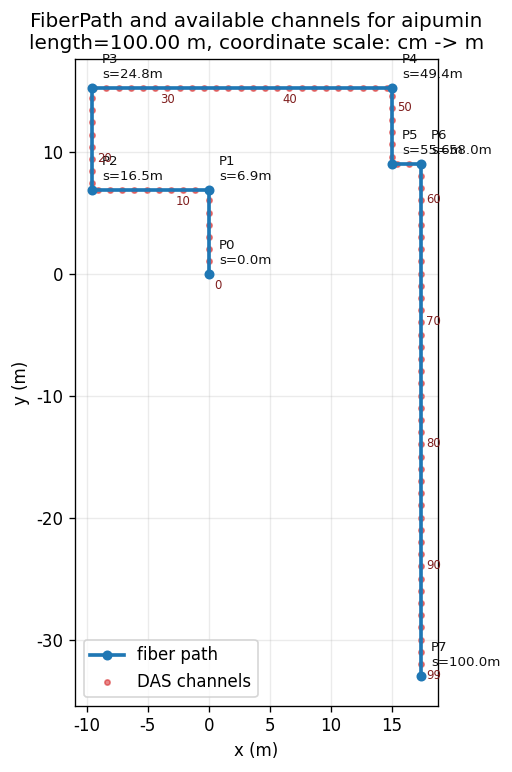

In [83]:
def read_csv_header(csv_path):
    header = pd.read_csv(csv_path, nrows=0)
    channel_cols = [c for c in header.columns if re.match(r"^ch_\d+$", str(c))]
    if not channel_cols:
        channel_cols = list(header.columns)
    channel_cols = channel_cols[:ACTIVE_CHANNEL_COUNT]
    channel_ids = np.arange(len(channel_cols), dtype=int)
    return channel_cols, channel_ids


channel_cols, channel_ids = read_csv_header(SIGNAL_CSV)
print(f"CSV: {SIGNAL_CSV}")
print(f"channels: {len(channel_cols)}, first={channel_cols[0]}, last={channel_cols[-1]}")

fig, ax = plot_fiber_path(fiber_df, channel_ids=channel_ids, title=f"FiberPath and available channels for {NAME}")
available_png = CACHE_DIR / f"{NAME}_fiber_available_channels.png"
if SAVE_FIGURES:
    fig.savefig(available_png, bbox_inches="tight")
    print(f"Saved: {available_png}")
plt.show()

## 3. 完整信号热图：全时长短时能量并缓存

默认会扫描完整 CSV。缓存文件包含：`energy`、`frame_times`、`channel_ids` 和参数元信息。

In [84]:
def make_cache_key(csv_path, channel_cols):
    st = Path(csv_path).stat()
    payload = {
        "csv": str(Path(csv_path).resolve()),
        "size": st.st_size,
        "mtime_ns": st.st_mtime_ns,
        "fs": DAS_FS,
        "win_ms": ENERGY_WIN_MS,
        "step_ms": ENERGY_STEP_MS,
        "time_start_s": TIME_START_S,
        "time_end_s": TIME_END_S,
        "active_channel_count": ACTIVE_CHANNEL_COUNT,
        "channel_length_m": CHANNEL_LENGTH_M,
        "channels": channel_cols,
    }
    raw = json.dumps(payload, ensure_ascii=False, sort_keys=True).encode("utf-8")
    return hashlib.sha1(raw).hexdigest()[:16], payload


def compute_energy_heatmap_from_csv(csv_path, channel_cols):
    fs = float(DAS_FS)
    win_samples = max(1, int(round(ENERGY_WIN_MS * 1e-3 * fs)))
    step_samples = max(1, int(round(ENERGY_STEP_MS * 1e-3 * fs)))
    start_sample = 0 if TIME_START_S is None else max(0, int(round(TIME_START_S * fs)))
    end_sample = None if TIME_END_S is None else max(start_sample + win_samples, int(round(TIME_END_S * fs)))

    energies = []
    frame_times = []
    carry = np.empty((0, len(channel_cols)), dtype=np.float64)
    carry_start_abs = 0
    rows_seen = 0
    next_frame_start = start_sample

    for chunk_idx, chunk in enumerate(pd.read_csv(csv_path, usecols=channel_cols, chunksize=CSV_CHUNKSIZE_ROWS)):
        values = chunk.to_numpy(dtype=np.float64, copy=False)
        chunk_start_abs = rows_seen
        rows_seen += values.shape[0]

        if len(carry):
            block = np.vstack([carry, values])
            block_start_abs = carry_start_abs
        else:
            block = values
            block_start_abs = chunk_start_abs

        block_end_abs = block_start_abs + block.shape[0]
        compute_until = block_end_abs if end_sample is None else min(block_end_abs, end_sample)

        while next_frame_start + win_samples <= compute_until:
            local = next_frame_start - block_start_abs
            if local < 0 or local + win_samples > block.shape[0]:
                break
            frame = block[local:local + win_samples]
            energies.append(np.mean(frame * frame, axis=0).astype(np.float32))
            frame_times.append((next_frame_start + win_samples / 2.0) / fs)
            next_frame_start += step_samples

        if end_sample is not None and rows_seen >= end_sample:
            break

        keep_from_abs = max(next_frame_start, block_end_abs - win_samples - step_samples)
        keep_from_abs = min(max(keep_from_abs, block_start_abs), block_end_abs)
        carry = block[keep_from_abs - block_start_abs:].copy()
        carry_start_abs = keep_from_abs

        if chunk_idx % 10 == 0:
            print(f"[Energy] chunks={chunk_idx + 1}, rows_seen={rows_seen:,}, frames={len(energies):,}")

    if not energies:
        raise ValueError("No energy frames were computed. Check TIME_START_S/TIME_END_S and CSV length.")

    energy = np.stack(energies, axis=1)  # [channels, frames]
    frame_times = np.asarray(frame_times, dtype=np.float64)
    return energy, frame_times


cache_key, cache_meta = make_cache_key(SIGNAL_CSV, channel_cols)
cache_path = CACHE_DIR / f"{NAME}_energy_{cache_key}.npz"

if cache_path.exists() and not FORCE_REBUILD_CACHE:
    z = np.load(cache_path, allow_pickle=False)
    energy = z["energy"]
    frame_times = z["frame_times"]
    channel_ids_cached = z["channel_ids"]
    print(f"[Cache] Loaded: {cache_path}")
else:
    energy, frame_times = compute_energy_heatmap_from_csv(SIGNAL_CSV, channel_cols)
    np.savez_compressed(
        cache_path,
        energy=energy,
        frame_times=frame_times,
        channel_ids=channel_ids,
        meta=json.dumps(cache_meta, ensure_ascii=False),
    )
    print(f"[Cache] Saved: {cache_path}")

print(f"energy shape [channels, frames] = {energy.shape}")
print(f"time range = {frame_times[0]:.3f}s .. {frame_times[-1]:.3f}s")

[Cache] Loaded: d:\DAS2Steps\output\notebook_cache\aipumin_energy_ed87a5a5f8ade7c4.npz
energy shape [channels, frames] = (100, 8357)
time range = 0.050s .. 208.950s


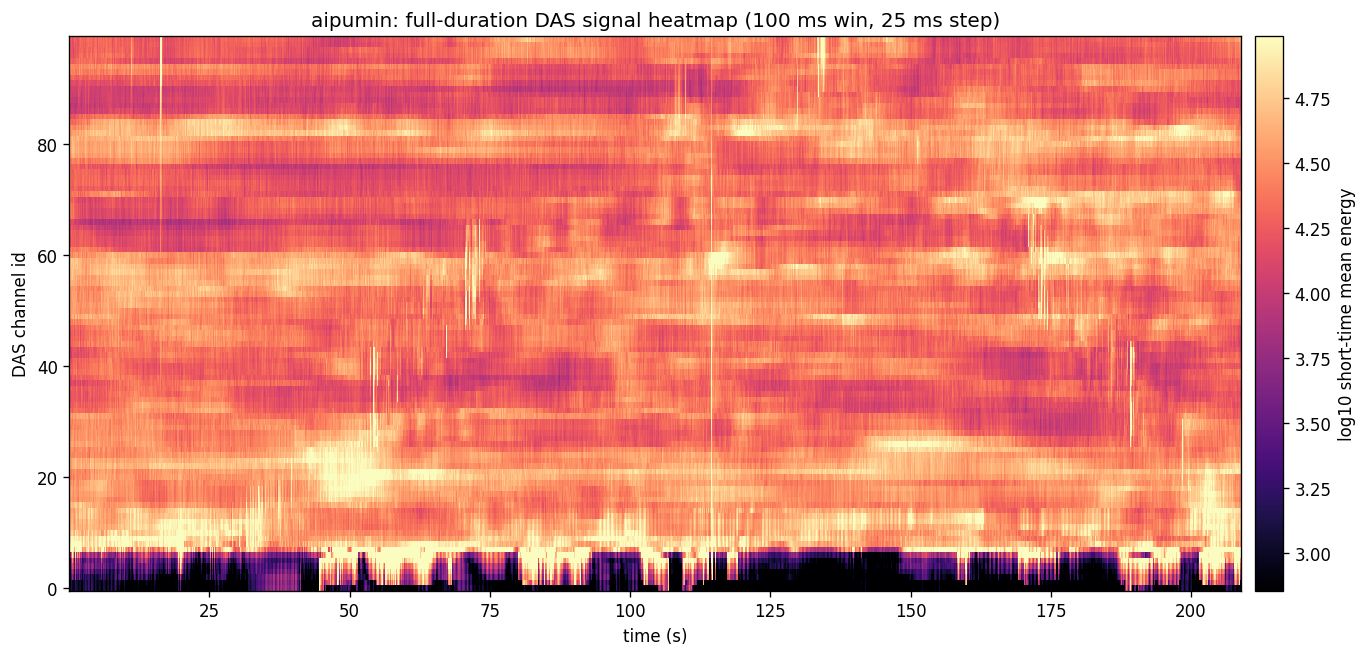

In [85]:
def maybe_decimate_for_display(matrix, times, max_bins=None):
    if max_bins is None or matrix.shape[1] <= max_bins:
        return matrix, times, 1
    factor = int(math.ceil(matrix.shape[1] / max_bins))
    n = (matrix.shape[1] // factor) * factor
    m = matrix[:, :n].reshape(matrix.shape[0], n // factor, factor).mean(axis=2)
    t = times[:n].reshape(n // factor, factor).mean(axis=1)
    return m, t, factor


def plot_signal_energy_heatmap(energy, frame_times, channel_ids, title):
    e_show, t_show, decim = maybe_decimate_for_display(energy, frame_times, DISPLAY_MAX_TIME_BINS)
    log_energy = np.log10(e_show + 1e-12)
    vmin, vmax = np.nanpercentile(log_energy, [2, 98])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = None, None

    fig, ax = plt.subplots(figsize=(15, 6))
    extent = [t_show[0], t_show[-1], channel_ids[0] - 0.5, channel_ids[-1] + 0.5]
    im = ax.imshow(
        log_energy,
        aspect="auto",
        origin="lower",
        extent=extent,
        cmap="magma",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
    )
    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("log10 short-time mean energy")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("DAS channel id")
    extra = "" if decim == 1 else f" display decimated x{decim}"
    ax.set_title(title + extra)
    return fig, ax


fig, ax = plot_signal_energy_heatmap(
    energy,
    frame_times,
    channel_ids,
    title=f"{NAME}: full-duration DAS signal heatmap ({ENERGY_WIN_MS:g} ms win, {ENERGY_STEP_MS:g} ms step)",
)
heatmap_png = CACHE_DIR / f"{NAME}_full_signal_energy_heatmap.png"
if SAVE_FIGURES:
    fig.savefig(heatmap_png, bbox_inches="tight")
    print(f"Saved: {heatmap_png}")
plt.show()

## 4. 通道到 2D 位置映射表

这个表用于后续把检测到的脚步通道映射到平面坐标。默认会保存到缓存目录。

In [86]:
xy, valid = channel_xy(channel_ids, fiber_df)
channel_map = pd.DataFrame({
    "channel_id": channel_ids,
    "distance_m": channel_distance_m(channel_ids),
    "x_m": xy[:, 0],
    "y_m": xy[:, 1],
    "within_fiber_path": valid,
})
channel_map_csv = CACHE_DIR / f"{NAME}_channel_to_xy.csv"
if SAVE_FIGURES:
    channel_map.to_csv(channel_map_csv, index=False)
    print(f"Saved: {channel_map_csv}")
channel_map.head(20)

,channel_id,distance_m,x_m,y_m,within_fiber_path
0,0,0.0,0.0,0.0,True
1,1,1.0,0.0,1.0,True
2,2,2.0,0.0,2.0,True
3,3,3.0,0.0,3.0,True
4,4,4.0,0.0,4.0,True
5,5,5.0,0.0,5.0,True
6,6,6.0,0.0,6.0,True
7,7,7.0,-0.1,6.9,True
8,8,8.0,-1.1,6.9,True
9,9,9.0,-2.1,6.9,True


## 5. 阶段一：数据预处理与候选频带对比

目标：把原始 2000 Hz DAS 信号变成适合脚步检测和定位的矩阵。这里先不直接照搬论文频段，而是对同一段数据生成候选频带对比：原始 c-t 图、滤波后 c-t 图、平均 PSD、单通道时域波形。阶段一默认显示全通道、全时间的 c-t 图；只有把 `BAND_COMPARE_MAX_PLOT_S` 改成秒数时才会截短用于调试。

这里的 c-t 图来自 DAS 矩阵 `X` 或 `Y`，纵轴是通道 `c`，横轴是时间 `t`。`raw` 图不是原始 ADC 直接画出，而是先线性去趋势、按通道 MAD 归一化；现在不做初始降采样，采样率保持 `DAS_FS = 2000 Hz`。band 图是在同样处理后再做候选带通滤波。

mean PSD 是所有通道 Welch PSD 的平均：它把每个频率上的平均能量画出来，用来判断脚步能量主要落在哪些频段、环境噪声或设备噪声集中在哪里，以及候选带通是否把有用能量保留下来。`Single-channel waveform` 固定用 `SINGLE_CHANNEL_PLOT_CHANNEL = 50`，方便在不同频带之间比较同一个通道的脚步冲击形态。

默认输出在当前 cell 下方显示；如果需要同时保存到 `results/preprocessing/`，把 `SAVE_FIGURES = True`。


Loaded X: (100, 418001) (C, T), duration=209.00s


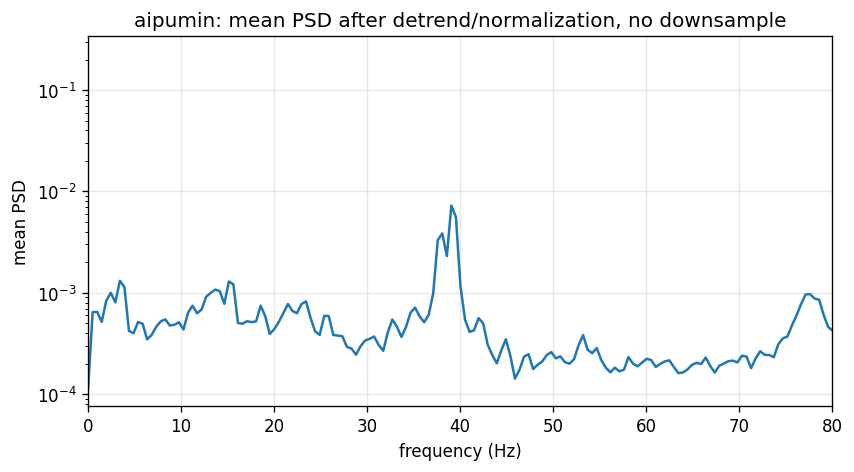

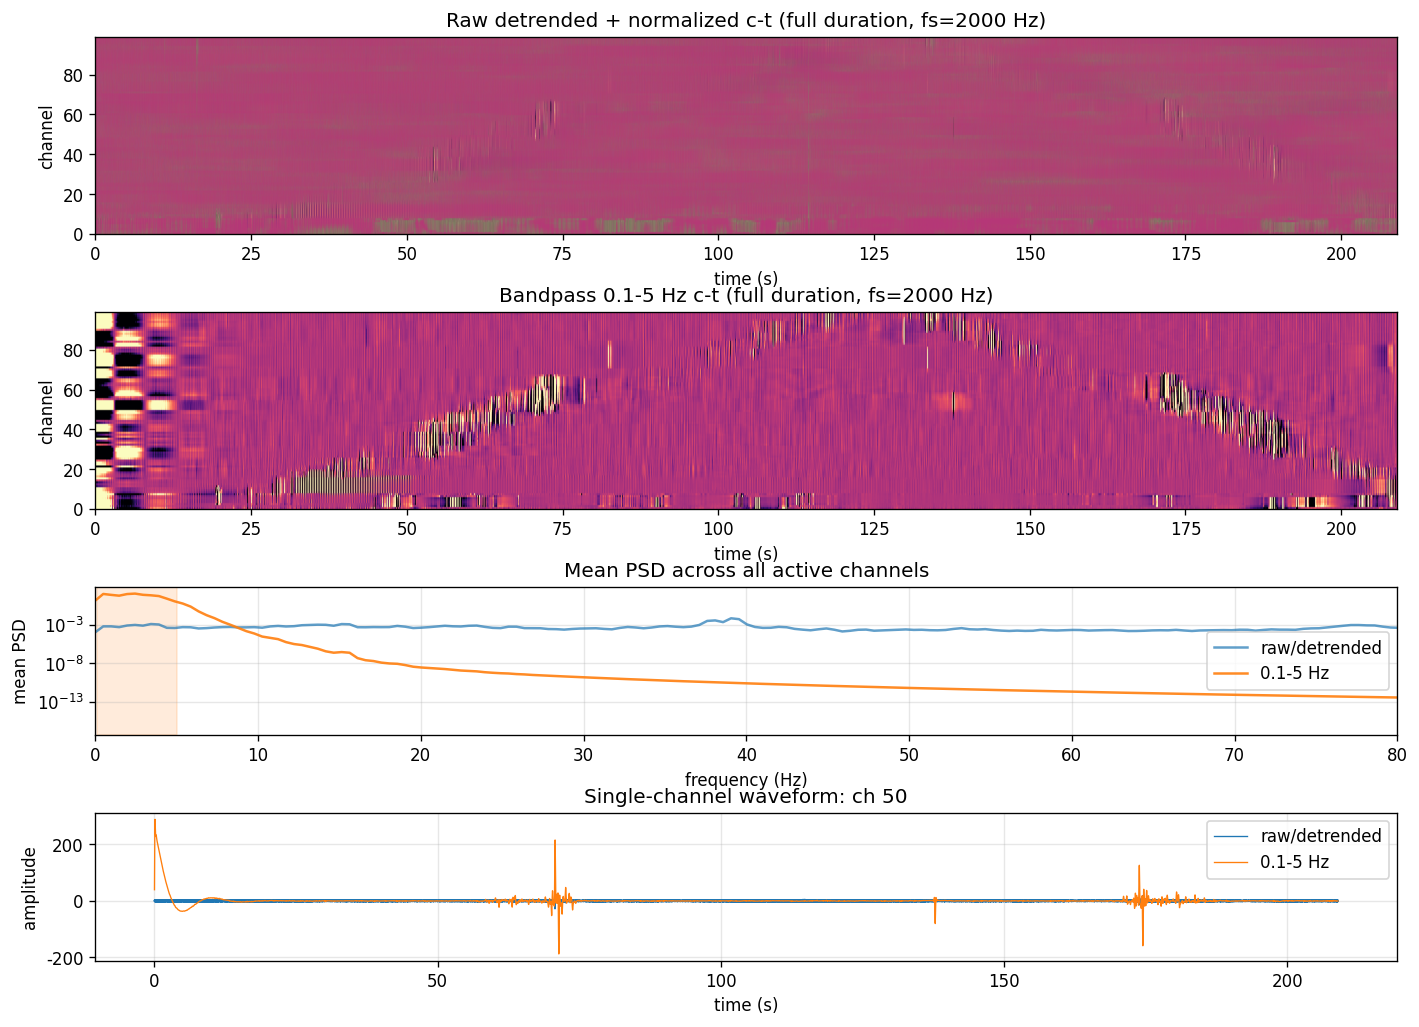

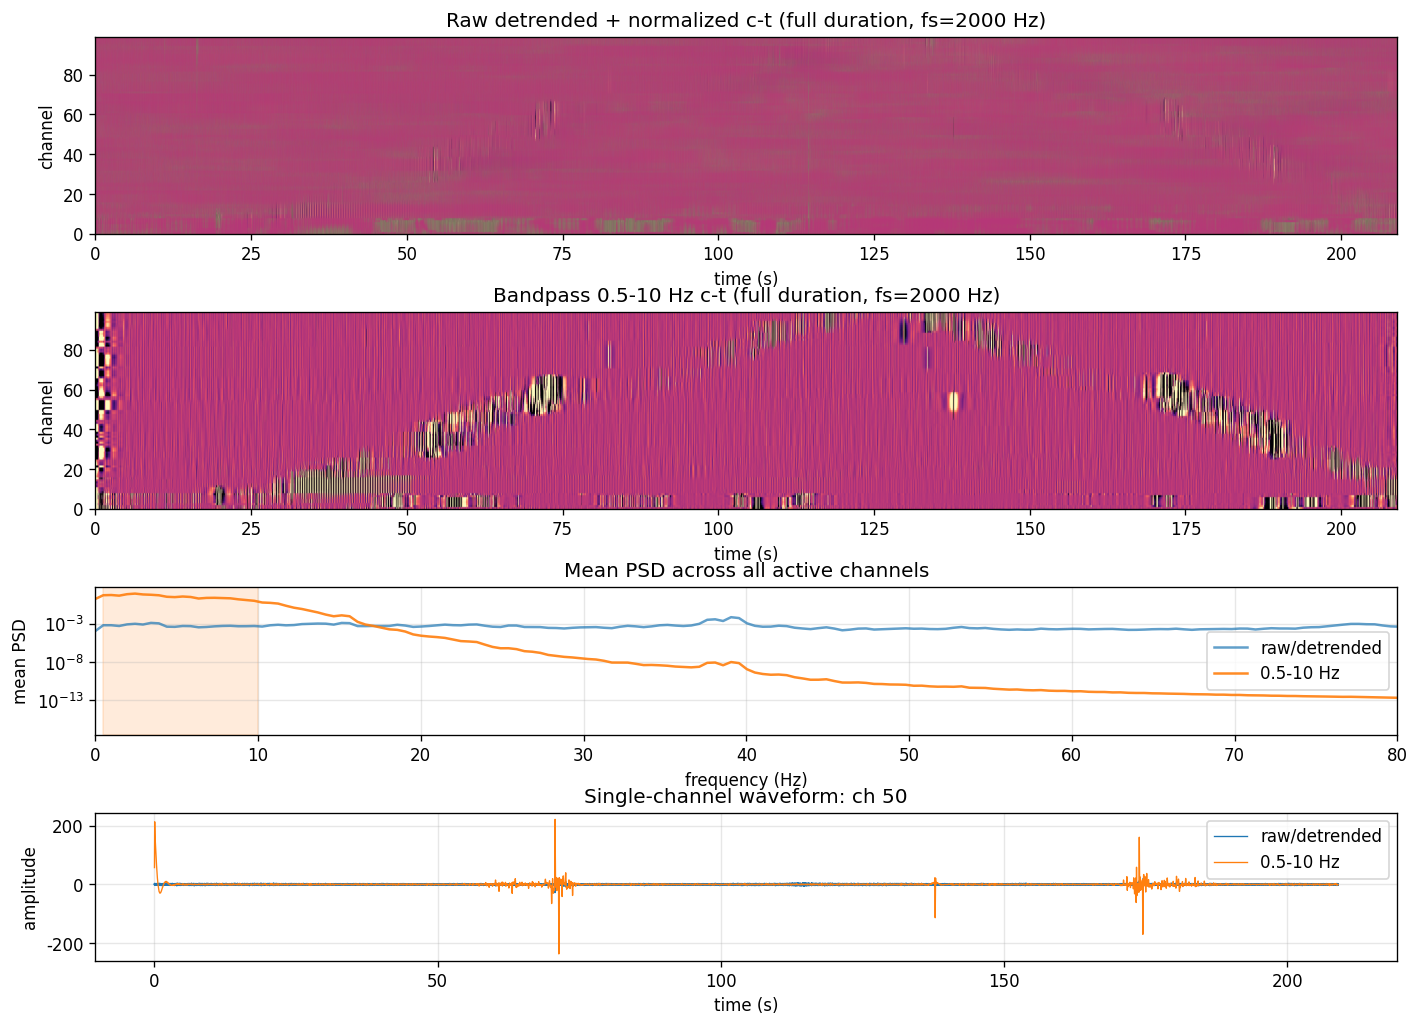

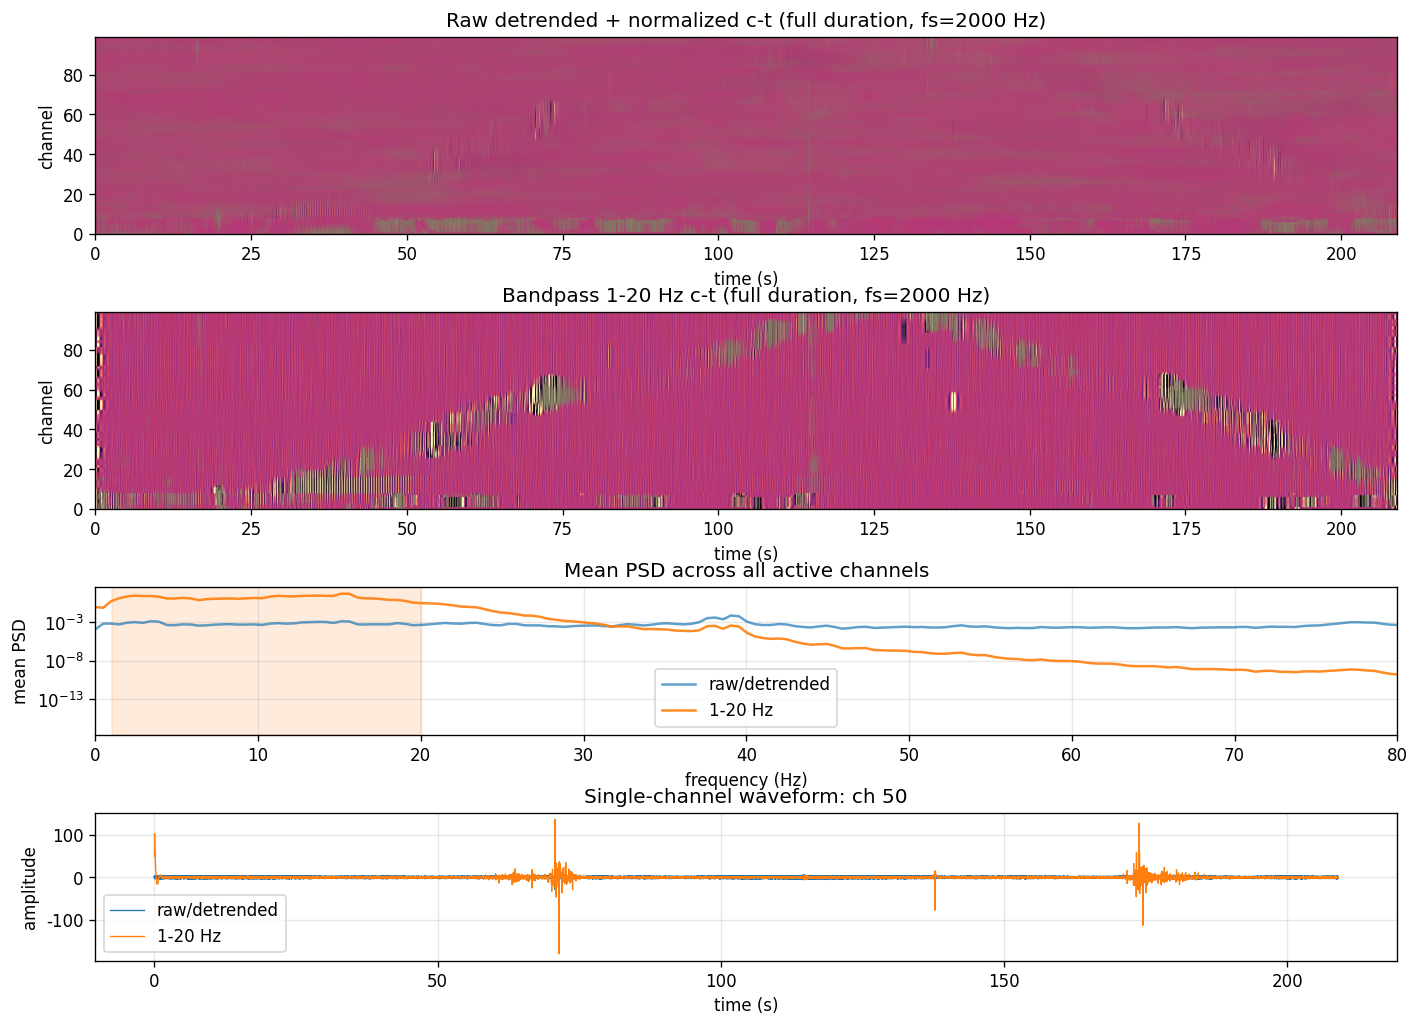

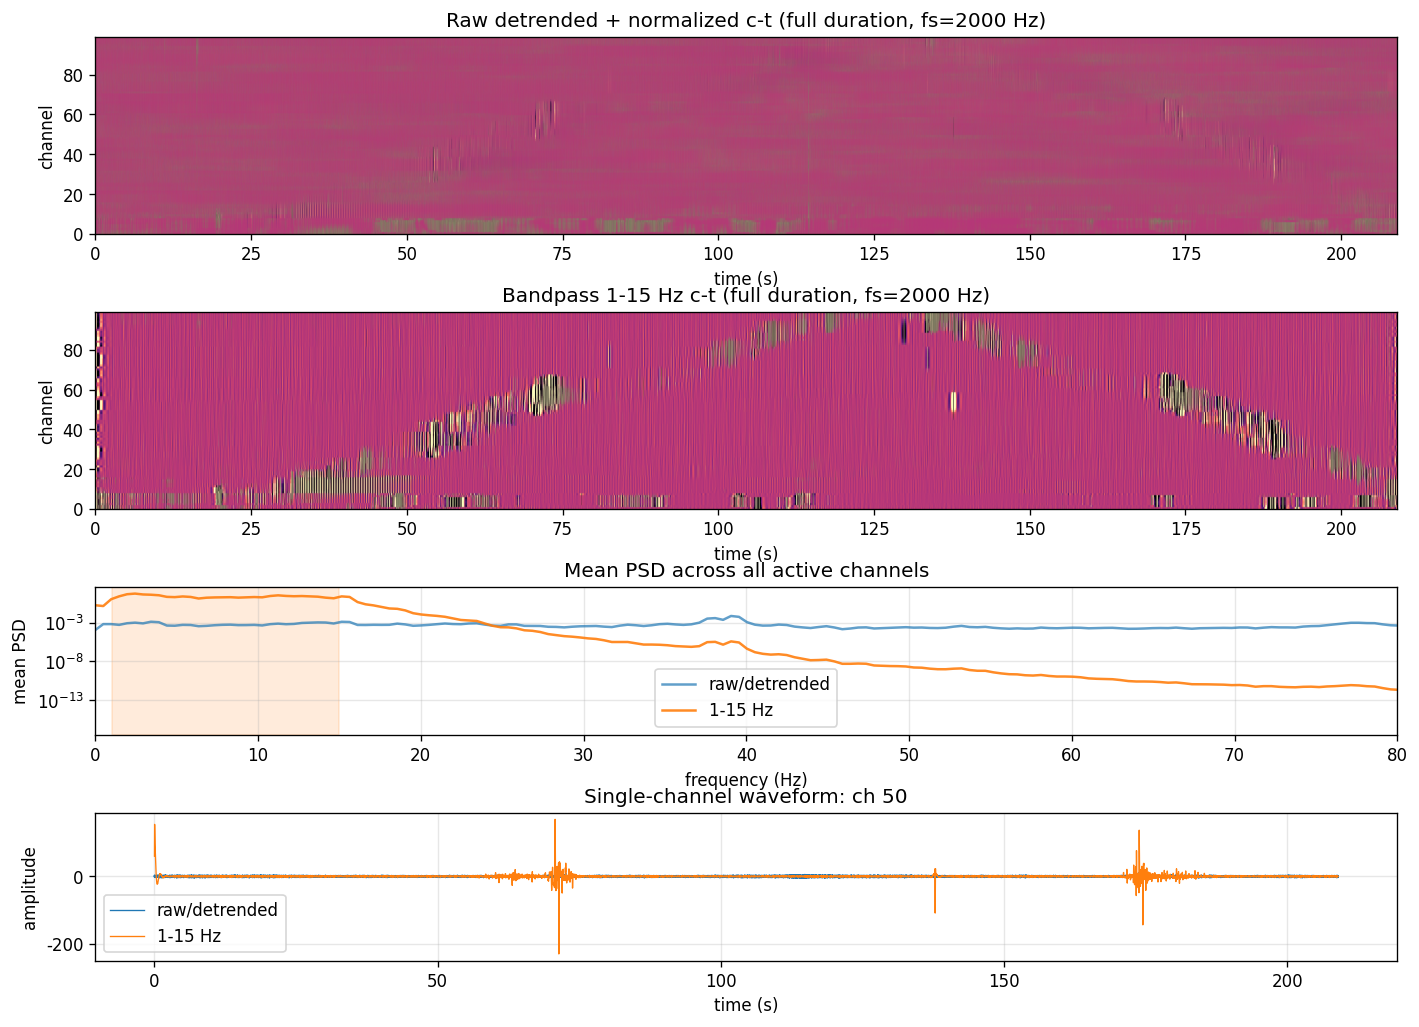

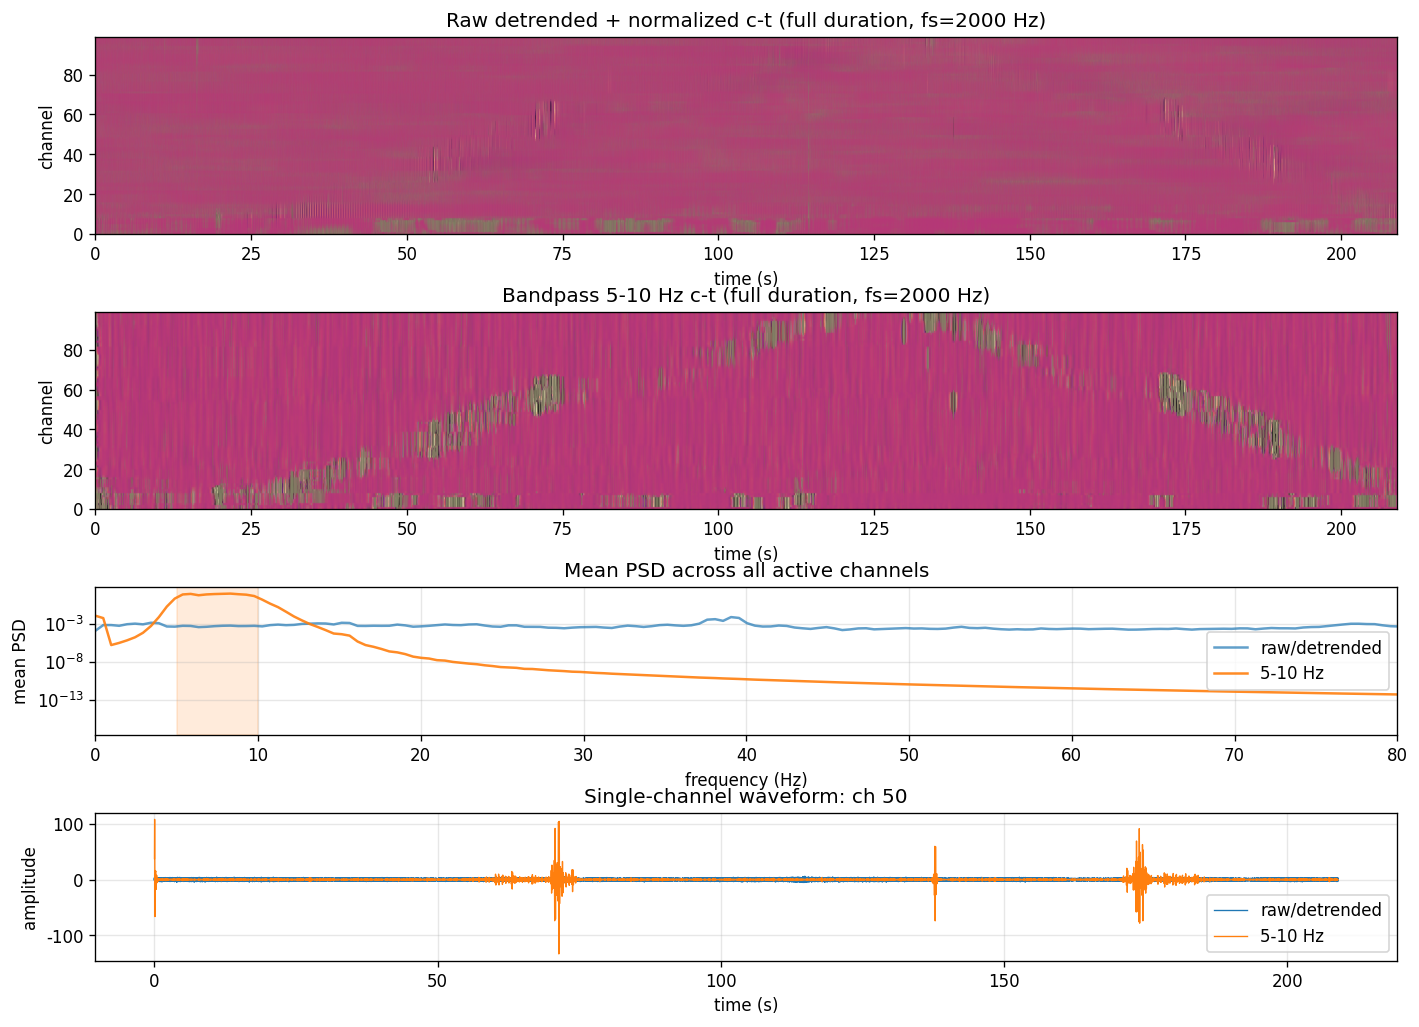

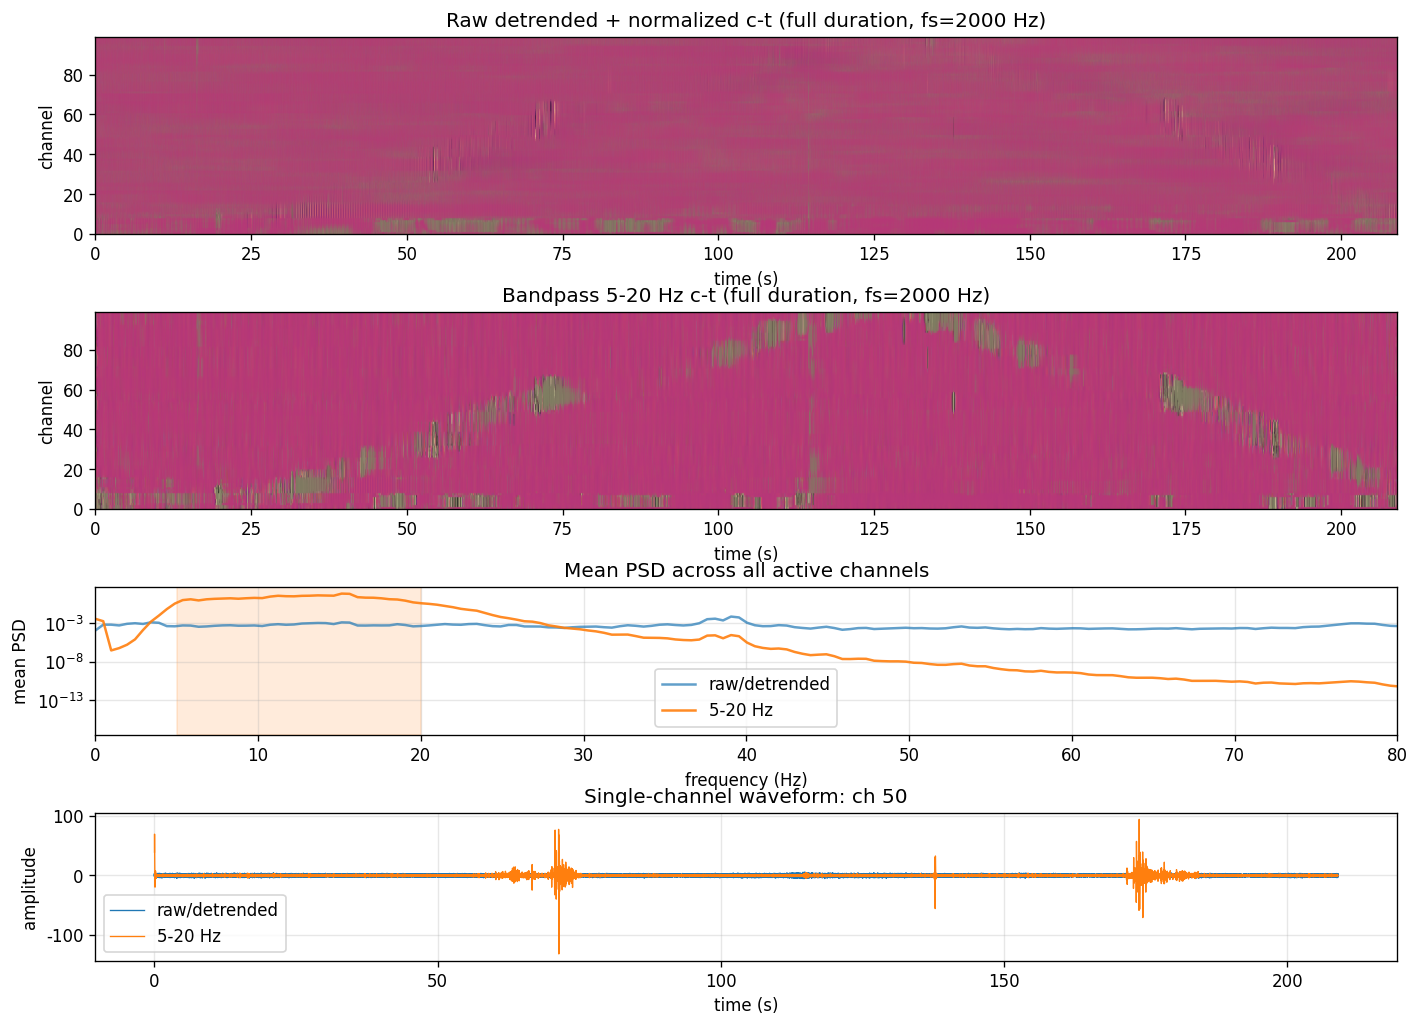

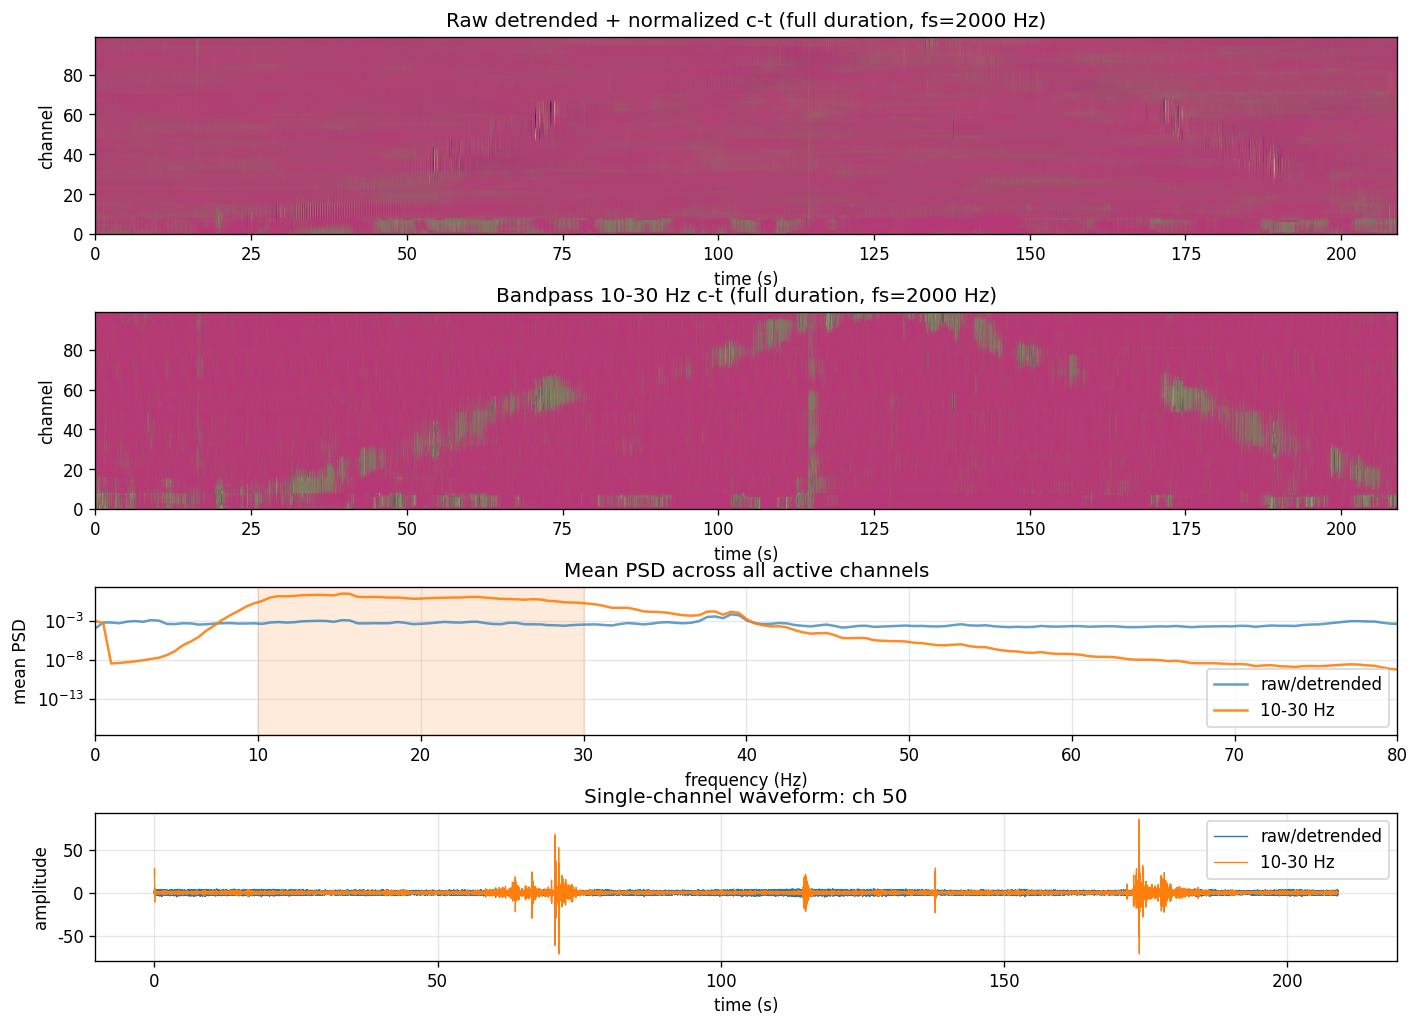

# Chosen Band Report (aipumin)

This notebook has generated visual comparisons for candidate bands: `[(0.1, 5), (0.5, 10), (1, 20), (1, 15), (5, 10), (5, 20), (10, 30)]`.

Current preprocessing keeps the native sampling rate unless `PREPROCESS_DOWNSAMPLE_TO` is changed. With the default setting, all candidate c-t images and PSD curves use `fs = 2000 Hz`.

Manual review checklist:

- Which band shows the clearest diagonal/continuous footstep trajectory in the c-t plot?
- Which band suppresses stationary/environmental noise best in quiet intervals?
- Which band gives the sharpest single-foot impulse on channel `50`?
- Are there two slope families that could correspond to Rayleigh / SH arrivals?

Current detection default follows `TDMS2FilteredSignalPlot.py`: `DETECTION_BAND = (5, 10)` with RMS envelope + MAD thresholding.

Selected CHOSEN_BAND=(5, 10); Y shape=(100, 418001), FS_PRE=2000.0


In [87]:
from IPython.display import Markdown, display
from scipy import signal

BANDS = [
    (0.1, 5),
    (0.5, 10),
    (1, 20),
    (1, 15),
    (5, 10),
    (5, 20),
    (10, 30),
]

RESULTS_ROOT = PROJECT_ROOT / "results"
PREPROCESSING_DIR = RESULTS_ROOT / "preprocessing"


def _maybe_savefig(fig, path):
    if SAVE_FIGURES:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight", dpi=200)
        print(f"Saved: {path}")


def _display_report_markdown(text, path=None):
    display(Markdown(text))
    if SAVE_FIGURES and path is not None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(text, encoding="utf-8")
        print(f"Saved: {path}")


def load_active_das_matrix(csv_path, channel_cols, dtype=np.float32, max_duration_s=None):
    """Load active channels from signal CSV as X with shape (C, T)."""
    nrows = None if max_duration_s is None else int(round(max_duration_s * DAS_FS))
    df = pd.read_csv(csv_path, usecols=channel_cols, nrows=nrows)
    X = df.to_numpy(dtype=dtype, copy=False).T
    print(f"Loaded X: {X.shape} (C, T), duration={X.shape[1] / DAS_FS:.2f}s")
    return X


def _robust_channel_normalize(X, mode="channel_mad"):
    X = np.asarray(X, dtype=np.float32)
    if mode is None or mode == "none":
        return X
    if mode == "channel_mad":
        med = np.median(X, axis=1, keepdims=True)
        mad = np.median(np.abs(X - med), axis=1, keepdims=True)
        return (X - med) / (1.4826 * mad + 1e-6)
    if mode == "channel_zscore":
        mu = np.mean(X, axis=1, keepdims=True)
        sd = np.std(X, axis=1, keepdims=True)
        return (X - mu) / (sd + 1e-6)
    raise ValueError(f"Unknown normalize mode: {mode}")


def _sos_filter(X, fs, bandpass=None):
    if bandpass is None:
        return X
    low, high = bandpass
    nyq = fs / 2.0
    if low is None or low <= 0:
        sos = signal.butter(4, high / nyq, btype="lowpass", output="sos")
    elif high is None or high >= nyq:
        sos = signal.butter(4, low / nyq, btype="highpass", output="sos")
    else:
        sos = signal.butter(4, [low / nyq, high / nyq], btype="bandpass", output="sos")
    return signal.sosfiltfilt(sos, X, axis=1).astype(np.float32)


def preprocess_das(
    X,
    fs,
    downsample_to=None,
    bandpass=(0.5, 20.0),
    detrend=True,
    normalize="channel_mad",
):
    """
    输入:
        X: (C, T)
        fs: 原采样率，例如 2000 Hz
        downsample_to: None 表示保持原始采样率；给定数值时才降采样
    输出:
        Y: 预处理后 DAS, shape (C, T')
        fs_new: 新采样率
    """
    Y = np.asarray(X, dtype=np.float32)
    if detrend:
        Y = signal.detrend(Y, axis=1, type="linear").astype(np.float32)

    fs_new = float(fs)
    if downsample_to is not None and downsample_to < fs:
        g = math.gcd(int(round(fs)), int(round(downsample_to)))
        up = int(round(downsample_to)) // g
        down = int(round(fs)) // g
        Y = signal.resample_poly(Y, up=up, down=down, axis=1).astype(np.float32)
        fs_new = float(downsample_to)

    Y = _sos_filter(Y, fs_new, bandpass=bandpass)
    Y = _robust_channel_normalize(Y, mode=normalize)
    return Y.astype(np.float32), fs_new


def compute_mean_psd(X, fs, nperseg=4096):
    nperseg = min(nperseg, X.shape[1])
    freqs, psd = signal.welch(X, fs=fs, axis=1, nperseg=nperseg)
    return freqs, np.mean(psd, axis=0)


def _imshow_ct(ax, M, fs, title, percentile=(2, 98), cmap="magma"):
    Z = np.asarray(M, dtype=np.float32)
    vmin, vmax = np.nanpercentile(Z, percentile)
    extent = [0, Z.shape[1] / fs, 0, Z.shape[0] - 1]
    im = ax.imshow(Z, aspect="auto", origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("channel")
    return im


def plot_psd_mean(X, fs, title="Mean PSD"):
    freqs, pxx = compute_mean_psd(X, fs)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(freqs, pxx + 1e-20)
    ax.set_xlim(0, min(80, fs / 2))
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("mean PSD")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    _maybe_savefig(fig, PREPROCESSING_DIR / "psd_mean.png")
    plt.show()
    return fig, ax


def plot_band_compare(X_raw, fs, band, downsample_to=None, example_channel=None, max_plot_s=None):
    """Display one candidate band comparison below the current cell. max_plot_s=None means full duration."""
    Y, fs_new = preprocess_das(X_raw, fs, downsample_to=downsample_to, bandpass=band)
    raw_ds, raw_fs = preprocess_das(X_raw, fs, downsample_to=downsample_to, bandpass=None, detrend=True, normalize="channel_mad")

    n_plot = raw_ds.shape[1] if max_plot_s is None else min(raw_ds.shape[1], int(max_plot_s * raw_fs))
    duration_label = "full duration" if max_plot_s is None else f"{max_plot_s:g}s shown"
    if example_channel is None:
        example_channel = min(SINGLE_CHANNEL_PLOT_CHANNEL, Y.shape[0] - 1)

    freqs_raw, psd_raw = compute_mean_psd(raw_ds, raw_fs)
    freqs_y, psd_y = compute_mean_psd(Y, fs_new)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.2, 1.2, 0.9, 0.9], hspace=0.45)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])

    _imshow_ct(ax0, raw_ds[:, :n_plot], raw_fs, f"Raw detrended + normalized c-t ({duration_label}, fs={raw_fs:g} Hz)")
    _imshow_ct(ax1, Y[:, :n_plot], fs_new, f"Bandpass {band[0]}-{band[1]} Hz c-t ({duration_label}, fs={fs_new:g} Hz)")

    ax2.semilogy(freqs_raw, psd_raw + 1e-20, label="raw/detrended", alpha=0.7)
    ax2.semilogy(freqs_y, psd_y + 1e-20, label=f"{band[0]}-{band[1]} Hz", alpha=0.9)
    ax2.axvspan(band[0], band[1], color="tab:orange", alpha=0.15)
    ax2.set_xlim(0, min(80, fs_new / 2))
    ax2.set_xlabel("frequency (Hz)")
    ax2.set_ylabel("mean PSD")
    ax2.set_title("Mean PSD across all active channels")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    t = np.arange(n_plot) / fs_new
    ax3.plot(t, raw_ds[example_channel, :n_plot], lw=0.8, label="raw/detrended")
    ax3.plot(t, Y[example_channel, :n_plot], lw=0.8, label=f"{band[0]}-{band[1]} Hz")
    ax3.set_xlabel("time (s)")
    ax3.set_ylabel("amplitude")
    ax3.set_title(f"Single-channel waveform: ch {example_channel}")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    safe_band = f"{band[0]:g}_{band[1]:g}".replace(".", "p")
    _maybe_savefig(fig, PREPROCESSING_DIR / f"band_compare_{safe_band}.png")
    plt.show()
    return Y, fs_new, fig


def run_preprocessing_band_sweep(max_duration_s=None, max_plot_s=None):
    """Load active channels, plot PSD and candidate band comparisons."""
    X_raw = load_active_das_matrix(SIGNAL_CSV, channel_cols, max_duration_s=max_duration_s)
    raw_ds, raw_fs = preprocess_das(X_raw, DAS_FS, downsample_to=PREPROCESS_DOWNSAMPLE_TO, bandpass=None, detrend=True, normalize="channel_mad")
    plot_psd_mean(raw_ds, raw_fs, title=f"{NAME}: mean PSD after detrend/normalization, no downsample")

    band_outputs = {}
    for band in BANDS:
        Y, fs_new, _ = plot_band_compare(
            X_raw,
            DAS_FS,
            band,
            downsample_to=PREPROCESS_DOWNSAMPLE_TO,
            example_channel=SINGLE_CHANNEL_PLOT_CHANNEL,
            max_plot_s=max_plot_s,
        )
        band_outputs[band] = (Y, fs_new)

    report = f"""
# Chosen Band Report ({NAME})

This notebook has generated visual comparisons for candidate bands: `{BANDS}`.

Current preprocessing keeps the native sampling rate unless `PREPROCESS_DOWNSAMPLE_TO` is changed. With the default setting, all candidate c-t images and PSD curves use `fs = {DAS_FS:g} Hz`.

Manual review checklist:

- Which band shows the clearest diagonal/continuous footstep trajectory in the c-t plot?
- Which band suppresses stationary/environmental noise best in quiet intervals?
- Which band gives the sharpest single-foot impulse on channel `{SINGLE_CHANNEL_PLOT_CHANNEL}`?
- Are there two slope families that could correspond to Rayleigh / SH arrivals?

Current detection default follows `TDMS2FilteredSignalPlot.py`: `DETECTION_BAND = {DETECTION_BAND}` with RMS envelope + MAD thresholding.
""".strip()
    _display_report_markdown(report, PREPROCESSING_DIR / "chosen_band_report.md")
    return X_raw, band_outputs


CHOSEN_BAND = DETECTION_BAND

if RUN_PREPROCESSING_ON_EXECUTE:
    X_RAW, BAND_OUTPUTS = run_preprocessing_band_sweep(
        max_duration_s=PREPROCESSING_MAX_DURATION_S,
        max_plot_s=BAND_COMPARE_MAX_PLOT_S,
    )
    Y, FS_PRE = BAND_OUTPUTS[CHOSEN_BAND]
    print(f"Selected CHOSEN_BAND={CHOSEN_BAND}; Y shape={Y.shape}, FS_PRE={FS_PRE}")


## 6. 阶段二：脚步事件检测

目标：先检测脚步发生的时间窗口，不急于精确定位每一脚。当前版本不再把 STA/LTA 作为主检测器；STA/LTA 对这批数据容易受局部尖峰和长尾振动影响，先保留为诊断函数。

主流程改成当前仓库 `TDMS2FilteredSignalPlot.py` 的思路：`DETECTION_BAND = (5, 10)` 带通后，计算 `0.5 s` 窗、`0.1 s` 步长的 RMS envelope，对每个通道用 MAD 自适应阈值生成 mask，再从 mask 的时间聚集程度里提取 footstep event 窗口。图里会在带通信号 c-t 图和 Log RMS envelope 图上叠加识别到的 mask 点与 event 窗口。

默认图表和事件表直接显示在当前 cell 输出下；如果 `SAVE_FIGURES = True`，会额外写到 `results/detection/`。


Detection uses DETECTION_BAND=(5, 10); Y_DET shape=(100, 418001), FS_DET=2000.0


,event_id,t_center,t_start,t_end,n_picks,peak_channel,score
0,0,0.25,0.0,2.3,406,57,1.333832
1,1,5.95,5.6,6.4,12,7,0.410472
2,2,20.05,18.6,21.4,170,9,1.779148
3,3,24.45,23.1,25.8,83,8,0.569301
4,4,31.65,27.5,41.2,1286,11,1.713459
5,5,44.25,41.7,46.8,357,0,1.199683
6,6,48.45,47.9,50.0,148,1,1.136911
7,7,59.25,50.5,68.0,2782,43,1.304292
8,8,70.75,69.0,75.8,1068,55,1.488220
9,9,78.25,77.3,79.2,96,55,0.391230


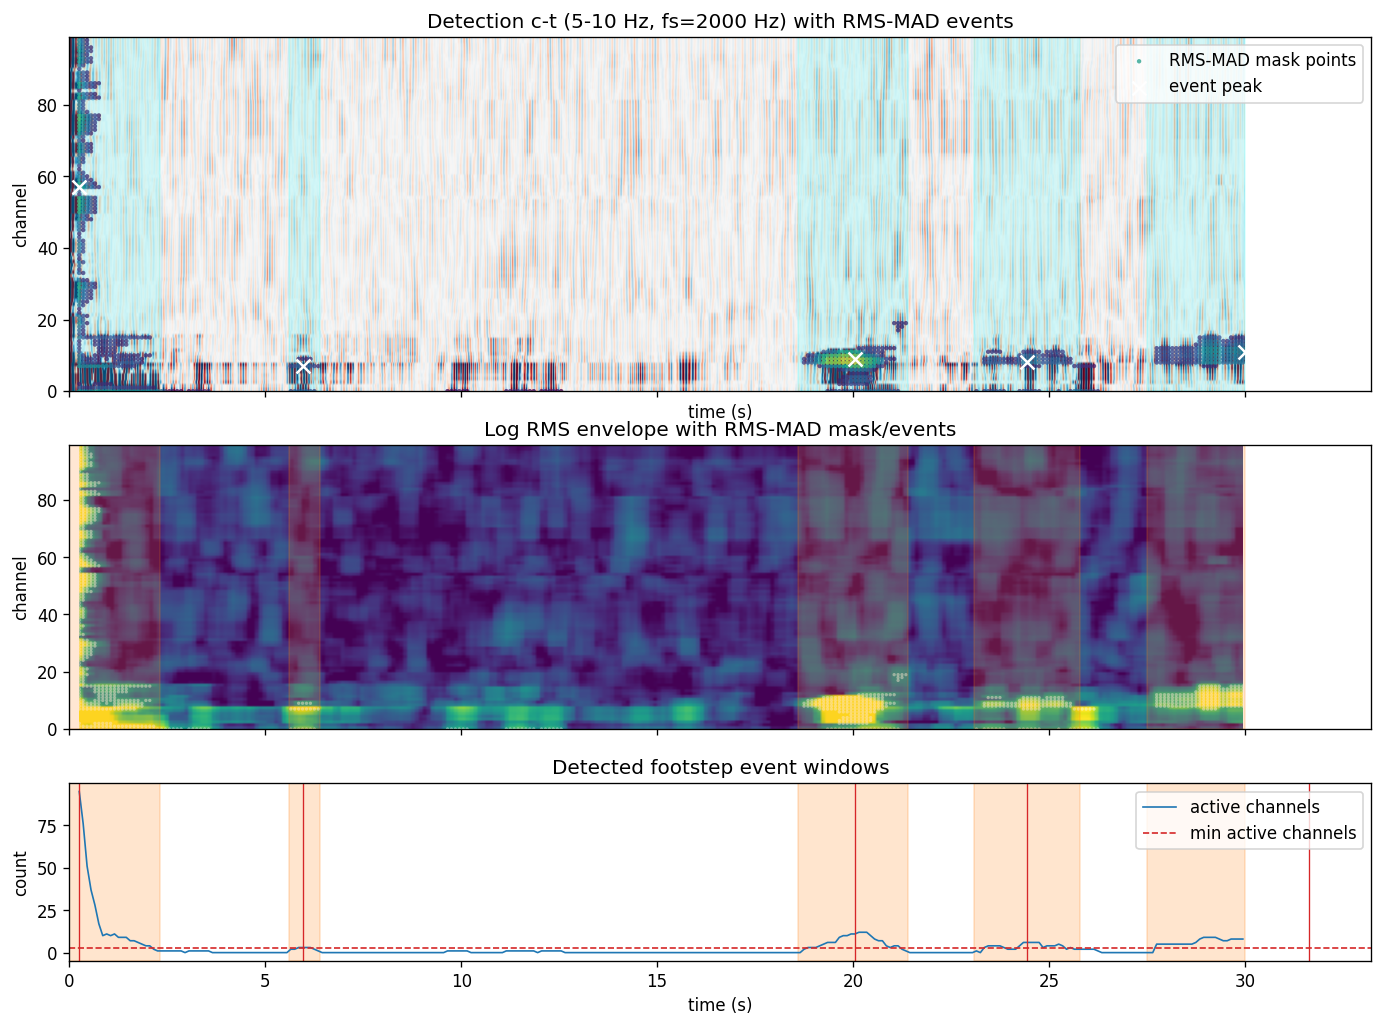

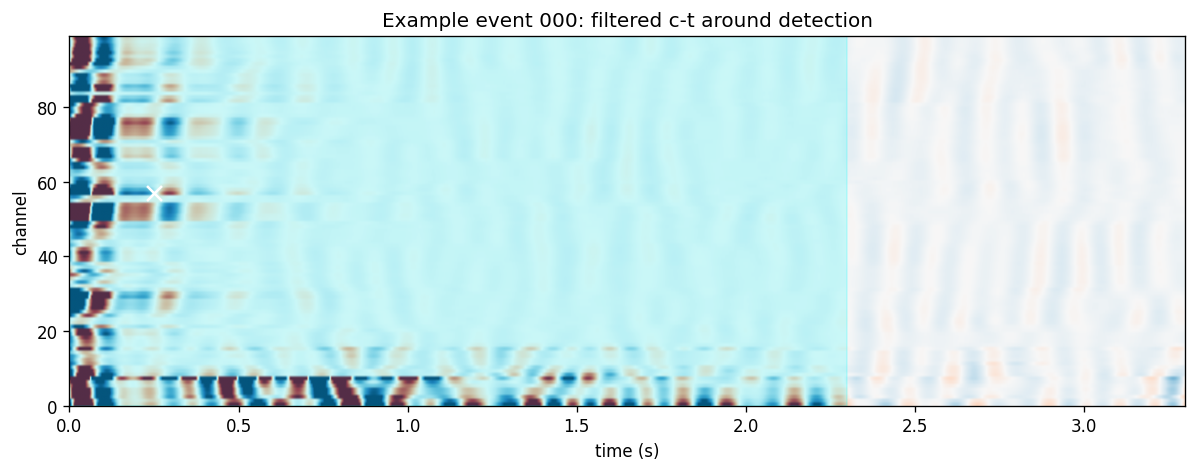

# Detection Report (aipumin)

- Detector: RMS envelope + per-channel MAD mask, adapted from `TDMS2FilteredSignalPlot.py`.
- Bandpass: `5-10 Hz`.
- Sampling rate after preprocessing: `2000 Hz`.
- Envelope window / hop: `0.5s / 0.1s`.
- MAD k: `2.5`.
- RMS-MAD mask points: `16082`.
- Detected event windows: `31`.
- Large connected components in mask: `33` with min area `50`.

STA/LTA is still implemented above for diagnostics, but it is not used as the default detector because it was producing poor picks on this dataset.

Next review items:

- Do the white mask points sit on visible high-energy arrivals in the c-t image?
- Are event windows split at individual footsteps, or do `DETECTION_MERGE_GAP_S` / `DETECTION_MIN_ACTIVE_CHANNELS` need tightening?
- Do peak channels follow a physically plausible walking trajectory?

In [88]:
from scipy.ndimage import binary_closing, label
from sklearn.cluster import DBSCAN

DETECTION_DIR = RESULTS_ROOT / "detection"


def compute_envelope(Y, fs, method="hilbert", rms_win_sec=0.05):
    """Hilbert envelope or sample-level RMS envelope, preserving shape (C, T)."""
    Y = np.asarray(Y, dtype=np.float32)
    if method == "hilbert":
        return np.abs(signal.hilbert(Y, axis=1)).astype(np.float32)
    if method == "rms":
        win = max(1, int(round(rms_win_sec * fs)))
        kernel = np.ones(win, dtype=np.float32) / win
        return np.sqrt(signal.lfilter(kernel, [1.0], Y * Y, axis=1) + 1e-12).astype(np.float32)
    raise ValueError(f"Unknown envelope method: {method}")


def rms_envelope_frames(Y, fs, win_sec=0.5, hop_sec=0.1):
    """Repo-style RMS envelope. Input Y is (C, T); output env_log is (C, n_frames)."""
    Y = np.asarray(Y, dtype=np.float32)
    win = int(round(win_sec * fs))
    hop = int(round(hop_sec * fs))
    if win <= 1 or hop <= 0:
        raise ValueError("DETECTION_ENV_WIN_SEC and DETECTION_ENV_HOP_SEC must be positive")
    if Y.shape[1] < win:
        raise ValueError("Signal is shorter than the RMS envelope window")

    n_frames = 1 + (Y.shape[1] - win) // hop
    starts = np.arange(n_frames) * hop
    ends = starts + win
    energy = np.cumsum(Y * Y, axis=1, dtype=np.float64)
    energy = np.concatenate([np.zeros((Y.shape[0], 1), dtype=np.float64), energy], axis=1)
    sums = energy[:, ends] - energy[:, starts]
    env = np.sqrt(np.maximum(sums / float(win), 0.0)).astype(np.float32)
    env_log = np.log10(env + 1e-12).astype(np.float32)
    frame_times = (starts + win / 2.0) / fs
    return env, env_log, frame_times, win, hop


def channel_mad_threshold_mask(E, k=2.5):
    """Threshold each channel over time, matching TDMS2FilteredSignalPlot.py semantics after transposing."""
    med = np.nanmedian(E, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(E - med), axis=1, keepdims=True)
    thr = med + k * 1.4826 * mad
    return E > thr, thr.squeeze(1)


def _merge_close_events(events, gap_sec=0.25):
    if not events:
        return []
    merged = [dict(events[0])]
    for event in events[1:]:
        last = merged[-1]
        if event["t_start"] <= last["t_end"] + gap_sec:
            last["t_end"] = max(last["t_end"], event["t_end"])
            last["t_center"] = float((last["t_start"] + last["t_end"]) / 2.0)
            last["n_picks"] += event["n_picks"]
            if event["score"] > last["score"]:
                last["score"] = event["score"]
                last["peak_channel"] = event["peak_channel"]
        else:
            merged.append(dict(event))
    for i, event in enumerate(merged):
        event["event_id"] = i
    return merged


def detect_rms_mad_events(
    Y,
    fs,
    win_sec=0.5,
    hop_sec=0.1,
    mad_k=2.5,
    min_active_channels=3,
    min_duration_sec=0.08,
    merge_gap_sec=0.25,
    min_cc_area=50,
):
    """Detect event windows from repo-style log RMS envelope + per-channel MAD mask."""
    env, env_log, frame_times, win, hop = rms_envelope_frames(Y, fs, win_sec=win_sec, hop_sec=hop_sec)
    mask, thresholds = channel_mad_threshold_mask(env_log, k=mad_k)

    active_count = mask.sum(axis=0).astype(np.int32)
    excess = np.maximum(env_log - thresholds[:, None], 0.0)
    frame_score = np.nanpercentile(excess, 95, axis=0)
    active_frames = active_count >= min_active_channels

    raw_events = []
    start = None
    for i, active in enumerate(active_frames):
        if active and start is None:
            start = i
        is_last = i == len(active_frames) - 1
        if start is not None and ((not active) or is_last):
            end = i if not active else i + 1
            if end > start:
                t0 = float(frame_times[start] - win_sec / 2.0)
                t1 = float(frame_times[end - 1] + win_sec / 2.0)
                duration = t1 - t0
                if duration >= min_duration_sec:
                    event_mask = mask[:, start:end]
                    n_picks = int(event_mask.sum())
                    if n_picks > 0:
                        local_scores = np.where(event_mask, excess[:, start:end], -np.inf)
                        peak_flat = int(np.nanargmax(local_scores))
                        peak_channel, peak_frame_rel = np.unravel_index(peak_flat, local_scores.shape)
                        peak_frame = start + peak_frame_rel
                        raw_events.append({
                            "event_id": len(raw_events),
                            "t_center": float(frame_times[peak_frame]),
                            "t_start": max(0.0, t0),
                            "t_end": min(Y.shape[1] / fs, t1),
                            "n_picks": n_picks,
                            "peak_channel": int(peak_channel),
                            "score": float(np.nanmax(local_scores)),
                        })
            start = None

    events = _merge_close_events(raw_events, gap_sec=merge_gap_sec)

    pick_ch, pick_frame = np.nonzero(mask)
    pick_scores = excess[pick_ch, pick_frame]
    picks = [
        {"channel": int(c), "time": float(frame_times[f]), "score": float(s)}
        for c, f, s in zip(pick_ch, pick_frame, pick_scores)
    ]

    # Connected components are useful diagnostics for trajectory-like regions; event timing still comes from active frames.
    cc_structure = np.ones((3, 3), dtype=bool)
    labeled, n_labels = label(mask, structure=cc_structure)
    cc_areas = [int(np.sum(labeled == idx)) for idx in range(1, n_labels + 1)]
    large_cc_count = int(sum(area >= min_cc_area for area in cc_areas))

    aux = {
        "env": env,
        "env_log": env_log,
        "mask": mask,
        "thresholds": thresholds,
        "frame_times": frame_times,
        "frame_score": frame_score,
        "active_count": active_count,
        "active_frames": active_frames,
        "win": win,
        "hop": hop,
        "win_sec": win_sec,
        "hop_sec": hop_sec,
        "large_cc_count": large_cc_count,
        "cc_areas": cc_areas,
    }
    return events, picks, aux


def detect_energy_events(
    Y,
    fs,
    win_sec=0.1,
    hop_sec=0.02,
    threshold_method="mad",
    threshold_k=6.0,
    min_duration=0.08,
):
    """Legacy simple energy-window detector, kept for quick comparison."""
    env = compute_envelope(Y, fs, method="rms", rms_win_sec=win_sec)
    win = max(1, int(round(win_sec * fs)))
    hop = max(1, int(round(hop_sec * fs)))
    frame_scores = []
    frame_times = []
    for start in range(0, env.shape[1] - win + 1, hop):
        frame = env[:, start:start + win]
        ch_score = np.percentile(frame, 90, axis=1)
        frame_scores.append(float(np.percentile(ch_score, 90)))
        frame_times.append((start + win / 2) / fs)
    score = np.asarray(frame_scores, dtype=np.float32)
    times = np.asarray(frame_times, dtype=np.float64)

    if threshold_method == "mad":
        med = np.median(score)
        mad = np.median(np.abs(score - med))
        thr = med + threshold_k * 1.4826 * mad
    elif threshold_method == "percentile":
        thr = np.percentile(score, 95)
    else:
        raise ValueError(f"Unknown threshold_method: {threshold_method}")

    active = score > thr
    events = []
    start = None
    for i, is_active in enumerate(active):
        if is_active and start is None:
            start = i
        if start is not None and ((not is_active) or i == len(active) - 1):
            end = i if not is_active else i + 1
            if end > start and times[end - 1] - times[start] >= min_duration:
                local = score[start:end]
                peak = start + int(np.argmax(local))
                events.append({"t_start": float(times[start]), "t_end": float(times[end - 1]), "t_center": float(times[peak]), "score": float(np.max(local))})
            start = None
    return events, {"times": times, "score": score, "threshold": float(thr), "envelope": env}


def sta_lta_detector(
    y,
    fs,
    sta_sec=0.01,
    lta_sec=0.2,
    trigger_on=10,
    trigger_off=0.5,
):
    """Diagnostic single-channel STA/LTA. Not used as the default detector for this notebook."""
    y = np.asarray(y, dtype=np.float32)
    sta = max(1, int(round(sta_sec * fs)))
    lta = max(sta + 1, int(round(lta_sec * fs)))
    power = y * y
    kernel_sta = np.ones(sta, dtype=np.float32) / sta
    kernel_lta = np.ones(lta, dtype=np.float32) / lta
    sta_curve = signal.lfilter(kernel_sta, [1.0], power)
    lta_curve = signal.lfilter(kernel_lta, [1.0], power) + 1e-12
    ratio = sta_curve / lta_curve

    picks = []
    active = False
    start = 0
    for i, r in enumerate(ratio):
        if (not active) and r >= trigger_on and i >= lta:
            active = True
            start = i
        elif active and r <= trigger_off:
            end = i
            local = ratio[start:end]
            if len(local):
                j = start + int(np.argmax(local))
                picks.append({"time": float(j / fs), "score": float(ratio[j])})
            active = False
    return picks, ratio


def multichannel_sta_lta(Y, fs, params=None):
    """Diagnostic STA/LTA per channel and return [{channel, time, score}, ...]."""
    params = dict(params or {})
    picks = []
    ratios = []
    for c in range(Y.shape[0]):
        ch_picks, ratio = sta_lta_detector(Y[c], fs, **params)
        ratios.append(ratio.astype(np.float32))
        for p in ch_picks:
            picks.append({"channel": c, "time": p["time"], "score": p["score"]})
    return picks, np.stack(ratios, axis=0)


def associate_picks_dbscan(picks, eps_time=0.15, min_samples=10):
    """Simplified optional association: cluster arbitrary picks by time only."""
    if not picks:
        return []
    times = np.array([[p["time"]] for p in picks], dtype=np.float64)
    labels = DBSCAN(eps=eps_time, min_samples=min_samples).fit_predict(times)
    events = []
    event_id = 0
    for lab in sorted(set(labels)):
        if lab < 0:
            continue
        group = [p for p, l in zip(picks, labels) if l == lab]
        t = np.array([p["time"] for p in group], dtype=float)
        ch = np.array([p["channel"] for p in group], dtype=int)
        scores = np.array([p["score"] for p in group], dtype=float)
        peak_channel = int(ch[np.argmax(scores)])
        events.append({
            "event_id": event_id,
            "t_center": float(np.median(t)),
            "t_start": float(np.min(t)),
            "t_end": float(np.max(t)),
            "n_picks": int(len(group)),
            "peak_channel": peak_channel,
            "score": float(np.percentile(scores, 90)),
        })
        event_id += 1
    return events


def associate_picks_moveout(picks, fiber_xy, v_candidates):
    """Placeholder for moveout-aware association over candidate source locations/velocities."""
    raise NotImplementedError("Next step: cluster picks with a moveout model over candidate source locations/velocities.")


def _plot_env_heatmap(ax, aux, t_max):
    env_log = aux["env_log"]
    frame_times = aux["frame_times"]
    n_env = int(np.searchsorted(frame_times, t_max, side="right"))
    n_env = max(1, min(n_env, env_log.shape[1]))
    Z = env_log[:, :n_env]
    vmin, vmax = np.nanpercentile(Z, (5, 99))
    extent = [frame_times[0], frame_times[n_env - 1], 0, Z.shape[0] - 1]
    im = ax.imshow(Z, aspect="auto", origin="lower", extent=extent, cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_ylabel("channel")
    ax.set_title("Log RMS envelope with RMS-MAD mask/events")
    return im


def plot_detection_outputs(Y, fs, picks, events, aux=None, max_plot_s=None):
    t_max = Y.shape[1] / fs if max_plot_s is None else min(max_plot_s, Y.shape[1] / fs)
    n = int(t_max * fs)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1.6, 1]})

    _imshow_ct(axes[0], Y[:, :n], fs, f"Detection c-t ({DETECTION_BAND[0]}-{DETECTION_BAND[1]} Hz, fs={fs:g} Hz) with RMS-MAD events", cmap="RdBu_r", percentile=(1, 99))
    if picks:
        pt = np.array([p["time"] for p in picks])
        pc = np.array([p["channel"] for p in picks])
        ps = np.array([p["score"] for p in picks])
        m = pt <= t_max
        if np.sum(m) > 20000:
            idx = np.flatnonzero(m)
            keep = np.linspace(0, len(idx) - 1, 20000).astype(int)
            m2 = np.zeros_like(m, dtype=bool)
            m2[idx[keep]] = True
            m = m2
        axes[0].scatter(pt[m], pc[m], c=ps[m], s=7, cmap="viridis", edgecolors="none", alpha=0.75, label="RMS-MAD mask points")

    for e in events:
        if e["t_start"] <= t_max:
            axes[0].axvspan(e["t_start"], min(e["t_end"], t_max), color="cyan", alpha=0.14)
            axes[0].scatter(
                [min(e["t_center"], t_max)], [e["peak_channel"]],
                marker="x", s=70, c="white", linewidths=1.5,
                label="event peak" if e is events[0] else None,
                zorder=5,
            )
    if picks or events:
        axes[0].legend(loc="upper right")

    if aux is not None:
        _plot_env_heatmap(axes[1], aux, t_max)
        if picks:
            pt = np.array([p["time"] for p in picks])
            pc = np.array([p["channel"] for p in picks])
            m = pt <= t_max
            if np.sum(m) > 20000:
                idx = np.flatnonzero(m)
                keep = np.linspace(0, len(idx) - 1, 20000).astype(int)
                m2 = np.zeros_like(m, dtype=bool)
                m2[idx[keep]] = True
                m = m2
            axes[1].scatter(pt[m], pc[m], s=4, c="white", alpha=0.45, edgecolors="none")
        for e in events:
            if e["t_start"] <= t_max:
                axes[1].axvspan(e["t_start"], min(e["t_end"], t_max), color="tab:orange", alpha=0.18)

        m = aux["frame_times"] <= t_max
        axes[2].plot(aux["frame_times"][m], aux["active_count"][m], lw=1.0, color="tab:blue", label="active channels")
        axes[2].axhline(DETECTION_MIN_ACTIVE_CHANNELS, color="tab:red", ls="--", lw=1.0, label="min active channels")
        axes[2].set_ylabel("count")
        axes[2].legend(loc="upper right")

    for e in events:
        if e["t_start"] <= t_max:
            axes[2].axvspan(e["t_start"], min(e["t_end"], t_max), color="tab:orange", alpha=0.20)
            axes[2].axvline(e["t_center"], color="tab:red", lw=0.8)
    axes[2].set_xlabel("time (s)")
    axes[2].set_title("Detected footstep event windows")
    _maybe_savefig(fig, DETECTION_DIR / "picks_overlay.png")
    _maybe_savefig(fig, DETECTION_DIR / "events_timeline.png")
    plt.show()
    return fig


def plot_example_event(Y, fs, event, aux=None, pad_sec=1.0):
    t0 = max(0.0, event["t_start"] - pad_sec)
    t1 = min(Y.shape[1] / fs, event["t_end"] + pad_sec)
    i0 = int(t0 * fs)
    i1 = int(t1 * fs)
    fig, ax = plt.subplots(figsize=(12, 4))
    _imshow_ct(ax, Y[:, i0:i1], fs, f"Example event {event['event_id']:03d}: filtered c-t around detection", cmap="RdBu_r", percentile=(1, 99))
    ax.set_xlim(0, t1 - t0)
    ax.axvspan(event["t_start"] - t0, event["t_end"] - t0, color="cyan", alpha=0.18)
    ax.scatter([event["t_center"] - t0], [event["peak_channel"]], marker="x", s=80, c="white", linewidths=1.5)
    _maybe_savefig(fig, DETECTION_DIR / f"example_event_{event['event_id']:03d}.png")
    plt.show()
    return fig


def run_detection_stage(Y, fs, max_plot_s=30.0):
    events, picks, aux = detect_rms_mad_events(
        Y,
        fs,
        win_sec=DETECTION_ENV_WIN_SEC,
        hop_sec=DETECTION_ENV_HOP_SEC,
        mad_k=DETECTION_MAD_K,
        min_active_channels=DETECTION_MIN_ACTIVE_CHANNELS,
        min_duration_sec=DETECTION_MIN_EVENT_DURATION_S,
        merge_gap_sec=DETECTION_MERGE_GAP_S,
        min_cc_area=DETECTION_MIN_CC_AREA,
    )
    event_df = pd.DataFrame(events, columns=["event_id", "t_center", "t_start", "t_end", "n_picks", "peak_channel", "score"])
    display(event_df)
    plot_detection_outputs(Y, fs, picks, events, aux=aux, max_plot_s=max_plot_s)
    if events:
        plot_example_event(Y, fs, events[0], aux=aux, pad_sec=1.0)

    report = f"""
# Detection Report ({NAME})

- Detector: RMS envelope + per-channel MAD mask, adapted from `TDMS2FilteredSignalPlot.py`.
- Bandpass: `{DETECTION_BAND[0]}-{DETECTION_BAND[1]} Hz`.
- Sampling rate after preprocessing: `{fs:g} Hz`.
- Envelope window / hop: `{DETECTION_ENV_WIN_SEC}s / {DETECTION_ENV_HOP_SEC}s`.
- MAD k: `{DETECTION_MAD_K}`.
- RMS-MAD mask points: `{len(picks)}`.
- Detected event windows: `{len(events)}`.
- Large connected components in mask: `{aux['large_cc_count']}` with min area `{DETECTION_MIN_CC_AREA}`.

STA/LTA is still implemented above for diagnostics, but it is not used as the default detector because it was producing poor picks on this dataset.

Next review items:

- Do the white mask points sit on visible high-energy arrivals in the c-t image?
- Are event windows split at individual footsteps, or do `DETECTION_MERGE_GAP_S` / `DETECTION_MIN_ACTIVE_CHANNELS` need tightening?
- Do peak channels follow a physically plausible walking trajectory?
""".strip()
    _display_report_markdown(report, DETECTION_DIR / "detection_report.md")
    if SAVE_FIGURES:
        DETECTION_DIR.mkdir(parents=True, exist_ok=True)
        event_df.to_csv(DETECTION_DIR / "event_catalog.csv", index=False)
    return events, picks, {"aux": aux}


if RUN_DETECTION_ON_EXECUTE:
    if "X_RAW" not in globals():
        X_RAW = load_active_das_matrix(SIGNAL_CSV, channel_cols, max_duration_s=PREPROCESSING_MAX_DURATION_S)
    if "BAND_OUTPUTS" in globals() and DETECTION_BAND in BAND_OUTPUTS:
        Y_DET, FS_DET = BAND_OUTPUTS[DETECTION_BAND]
    else:
        Y_DET, FS_DET = preprocess_das(X_RAW, DAS_FS, downsample_to=PREPROCESS_DOWNSAMPLE_TO, bandpass=DETECTION_BAND)
    print(f"Detection uses DETECTION_BAND={DETECTION_BAND}; Y_DET shape={Y_DET.shape}, FS_DET={FS_DET}")
    EVENTS, PICKS, DETECTION_AUX = run_detection_stage(Y_DET, FS_DET, max_plot_s=DETECTION_MAX_PLOT_S)


## 7. 下一步路线：阶段三到阶段八

当前 notebook 已经具备阶段一和阶段二的可运行基础。下一轮建议按这个顺序继续推进：

1. 用阶段一图选出 `CHOSEN_BAND`。
2. 用阶段二得到稳定的 `EVENTS` 和 `PICKS`。
3. 在清晰事件上实现波速估计，再把速度送入 2D backprojection。
4. 最后补不确定性、可观测性、距离阈值、beamforming 和轨迹滤波。

下面先保留后续阶段的函数接口占位，避免 API 形状漂移；具体实现会在确认阶段一/二输出质量后继续填。

In [89]:
def estimate_wave_speed_for_event(Y, fs, event, fiber_xy, pick_method="sta_lta", v_range=(50, 1000)):
    raise NotImplementedError("Stage 3 next: fit travel-time slope for one clear event.")


def estimate_wave_speed_catalog(Y, fs, events, fiber_xy):
    raise NotImplementedError("Stage 3 next: batch wave-speed estimation over selected clear events.")


def make_grid(xmin, xmax, ymin, ymax, dx=0.25):
    xs = np.arange(xmin, xmax + 0.5 * dx, dx)
    ys = np.arange(ymin, ymax + 0.5 * dx, dx)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()]), xs, ys


def backproject_event(Y, fs, event, fiber_xy, grid_xy, v, use_envelope=True, channel_subset=None, time_window_sec=1.0, distance_weight=None):
    raise NotImplementedError("Stage 4 next: envelope backprojection over a 2D grid.")


def estimate_uncertainty_from_heatmap(heatmap, grid_xy, ratio=0.95):
    raise NotImplementedError("Stage 5 next: estimate 95%-of-peak uncertainty region.")


def compute_observability_map(fiber_xy, grid_xy, v, channel_subset_radius=40.0):
    raise NotImplementedError("Stage 5 next: compute geometric observability from delay-vector Jacobian.")


def compute_event_snr(Y, fs, event, noise_window_sec=2.0):
    raise NotImplementedError("Stage 6 next: event/noise amplitude ratio and SNR-vs-distance analysis.")


def coherent_beamform_event(Y, fs, event, fiber_xy, grid_xy, v, band=(5, 10)):
    raise NotImplementedError("Stage 7 optional: narrow-band coherent beamforming.")


def viterbi_track(heatmaps, grid_xy, times, vmax=2.0, smooth_lambda=1.0):
    raise NotImplementedError("Stage 8 next: grid Viterbi trajectory smoothing.")


def particle_filter_track(heatmaps, grid_xy, times, n_particles=2000, vmax=2.0):
    raise NotImplementedError("Stage 8 optional: particle-filter trajectory smoothing.")
